<a href="https://colab.research.google.com/github/atessberfin/voltradar/blob/main/notebooks/VoltRadar_Masters_Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **VoltRadar: Forecasting Import Growth and Monitoring Trade-Policy Interventions in Lithium-Ion Battery Markets**

# **1. Business Problem Understanding**

International market selection is commonly supported by analysing historical trade data to identify countries with growing demand. However, import trends alone may not provide a complete assessment because government interventions, including tariffs, subsidies and import restrictions, can strengthen or weaken a potential market opportunity. In practice, analysts often conduct this process manually by reviewing trade data and subsequently investigating relevant policy developments.

VoltRadar aims to partially automate this process for lithium-ion accumulators (HS 850760). The project will forecast country-level import growth using historical Trade Map data and examine whether the inclusion of structured Global Trade Alert intervention variables improves forecasting performance. The resulting predictions will support an explainable assessment of market growth, policy conditions and potential export opportunities.

# **2. Data Collection and Understanding**

This project uses two secondary datasets. Historical country-level import values for lithium-ion accumulators (HS 850760) were obtained from Trade Map. Trade-policy intervention records affecting the selected product were obtained from Global Trade Alert. The datasets will first be examined separately and will later be cleaned, transformed and integrated at the country-year level for modelling.


## **2.1. Importing Libraries**

In [57]:
!pip install -q openpyxl shap

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor)
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from sklearn.inspection import permutation_importance

## **2.2. Loading the Datasets**

In [7]:
trade_df = pd.read_excel(
    "/content/trade_map_data.xlsx",
    engine="openpyxl"
)

print("Trade Map dataset shape:", trade_df.shape)
display(trade_df.head())

Trade Map dataset shape: (231, 21)


,Importers,Imported value in 2006,Imported value in 2007,Imported value in 2008,Imported value in 2009,Imported value in 2010,Imported value in 2011,Imported value in 2012,Imported value in 2013,Imported value in 2014,Imported value in 2015,Imported value in 2016,Imported value in 2017,Imported value in 2018,Imported value in 2019,Imported value in 2020,Imported value in 2021,Imported value in 2022,Imported value in 2023,Imported value in 2024,Imported value in 2025
0,World,NaN,NaN,NaN,NaN,NaN,NaN,10170016.0,11449019.0,12961890.0,13682466.0,15174344.0,19312728.0,25672564.0,31038055.0,40249915.0,61900015.0,89087370.0,116620002.0,111605857.0,124000680.0
1,Germany,0.0,0.0,0.0,0.0,0.0,0.0,565425.0,676968.0,1031521.0,1313127.0,1614343.0,2247410.0,2857808.0,3707772.0,6406589.0,10358053.0,14411438.0,23313634.0,20051795.0,22974328.0
2,United States of America,0.0,0.0,0.0,0.0,0.0,0.0,1306942.0,1707471.0,1729944.0,1718175.0,1997259.0,2568701.0,3224108.0,3691381.0,4823512.0,8258723.0,13898653.0,18749588.0,23848685.0,20084555.0
3,Viet Nam,0.0,0.0,0.0,0.0,0.0,0.0,198721.0,182078.0,673182.0,668028.0,701292.0,1063209.0,1302762.0,1660844.0,2210261.0,3766166.0,3868655.0,3288450.0,3496012.0,4978530.0
4,"Korea, Republic of",0.0,0.0,0.0,0.0,0.0,0.0,464023.0,511797.0,462385.0,402507.0,394591.0,670951.0,1224303.0,1248932.0,1632726.0,3357021.0,5694928.0,8465963.0,4754948.0,4946958.0


In [8]:
gta_df = pd.read_csv(
    "/content/interventions.csv",
    low_memory=False
)

print("Global Trade Alert dataset shape:", gta_df.shape)
display(gta_df.head())

Global Trade Alert dataset shape: (1605, 19)


,Intervention ID,Intervention URL,State Act ID,State Act URL,State Act Title,GTA Evaluation,Implementing Jurisdictions,Implementation Level,Eligible Firm,Intervention Type,Mast Chapter,Affected Sectors,Affected Products,Affected Jurisdictions,Is Horizontal,Date Announced,Date Implemented,Date Removed,Is In Force
0,11086,https://globaltradealert.org/intervention/11086,3290,https://www.globaltradealert.org/state-act/3290,United States of America: Suspension of Argentina's GSP benefits,Red,United States of America,National,all,Import tariff,Tariff measures,"012, 013, 015, 016, 019, 021, 029, 032, 042, 043, 049, 151, 161, 163, 211, 212, 213, 214, 215, 2...","10631, 10632, 10633, 10639, 20230, 20890, 20910, 20990, 21091, 21092, 21093, 21099, 30245, 30246...","Argentina, Seychelles",False,2012-03-26,2012-05-29,2018-02-28,0
1,11360,https://globaltradealert.org/intervention/11360,4315,https://www.globaltradealert.org/state-act/4315,Lithuania: Liberalizations of the energy sector,Red,Lithuania,National,all,FDI: Entry and ownership rule,FDI measures,"171, 341, 345, 461, 464, 471, 472","271600, 290410, 290420, 290431, 290432, 290433, 290434, 290435, 290436, 290491, 290499, 290511, ...","Croatia, Finland, Hungary, Italy, Latvia, Luxembourg, Russia, Macedonia, United Kingdom",False,2010-10-06,2012-06-26,NaN,1
2,12536,https://globaltradealert.org/intervention/12536,8896,https://www.globaltradealert.org/state-act/8896,Russian Federation: Incentives for Special Investment Contracts in selected industries,Amber,Russia,National,all,Instrument unclear,Instrument unclear,"019, 029, 031, 032, 222, 232, 239, 261, 262, 263, 264, 265, 266, 267, 268, 271, 272, 273, 279, 2...","280110, 280120, 280130, 280200, 280300, 280410, 280421, 280429, 280430, 280440, 280450, 280461, ...","Azerbaijan, Argentina, Australia, Austria, Bahrain, Bangladesh, Armenia, Belgium, Bolivia, Bosni...",False,2015-07-16,NaN,NaN,0
3,13025,https://globaltradealert.org/intervention/13025,10379,https://www.globaltradealert.org/state-act/10379,Malaysia: Introduction of import license requirements for a large number of goods,Red,Malaysia,National,all,Import licensing requirement,"E: Non-automatic licensing, quotas etc.","019, 231, 232, 235, 250, 282, 341, 342, 352, 369, 391, 392, 393, 411, 412, 429, 435, 441, 445, 4...","110100, 170112, 170113, 170114, 170191, 170199, 170230, 170240, 170260, 170290, 240110, 240120, ...","Argentina, Australia, Austria, Bangladesh, Belgium, Brazil, Bulgaria, Myanmar, Cambodia, Canada,...",False,2013-03-01,2013-03-01,NaN,1
4,13055,https://globaltradealert.org/intervention/13055,10410,https://www.globaltradealert.org/state-act/10410,"EC: Fiji, Iraq, Marshall Islands, Samoa & Tonga scrapped from GSP",Red,"Austria, Belgium, Bulgaria, Croatia, Cyprus, Czechia, Denmark, Estonia, Finland, France, Germany...",Supranational,all,Import tariff,Tariff measures,"012, 015, 018, 019, 023, 029, 213, 214, 222, 223, 231, 233, 234, 236, 239, 241, 242, 243, 244, 2...","40510, 40520, 40590, 40711, 40719, 40721, 40729, 40790, 40900, 60210, 60220, 60230, 60240, 60290...","Fiji, Iraq, Marshall Islands, Tonga, Samoa",False,2015-11-05,2017-01-01,NaN,1


## **2.3. Dataset Overview**

In [9]:
dataset_overview = pd.DataFrame({
    "Dataset": [
        "Trade Map",
        "Global Trade Alert"
    ],
    "Rows": [
        trade_df.shape[0],
        gta_df.shape[0]
    ],
    "Columns": [
        trade_df.shape[1],
        gta_df.shape[1]
    ]
})

display(dataset_overview)

print("\nTrade Map columns:")
print(trade_df.columns.tolist())

print("\nGlobal Trade Alert columns:")
print(gta_df.columns.tolist())

,Dataset,Rows,Columns
0,Trade Map,231,21
1,Global Trade Alert,1605,19



Trade Map columns:
['Importers', 'Imported value in 2006', 'Imported value in 2007', 'Imported value in 2008', 'Imported value in 2009', 'Imported value in 2010', 'Imported value in 2011', 'Imported value in 2012', 'Imported value in 2013', 'Imported value in 2014', 'Imported value in 2015', 'Imported value in 2016', 'Imported value in 2017', 'Imported value in 2018', 'Imported value in 2019', 'Imported value in 2020', 'Imported value in 2021', 'Imported value in 2022', 'Imported value in 2023', 'Imported value in 2024', 'Imported value in 2025']

Global Trade Alert columns:
['Intervention ID', 'Intervention URL', 'State Act ID', 'State Act URL', 'State Act Title', 'GTA Evaluation', 'Implementing Jurisdictions', 'Implementation Level', 'Eligible Firm', 'Intervention Type', 'Mast Chapter', 'Affected Sectors', 'Affected Products', 'Affected Jurisdictions', 'Is Horizontal', 'Date Announced', 'Date Implemented', 'Date Removed', 'Is In Force']


In [10]:
def create_column_overview(dataframe):
    return pd.DataFrame({
        "Data Type": dataframe.dtypes.astype(str),
        "Non-Null Values": dataframe.notna().sum(),
        "Missing Values": dataframe.isna().sum(),
        "Unique Values": dataframe.nunique(dropna=True)
    })


print("Trade Map column overview:")
display(create_column_overview(trade_df))

print("\nGlobal Trade Alert column overview:")
display(create_column_overview(gta_df))

Trade Map column overview:


,Data Type,Non-Null Values,Missing Values,Unique Values
Importers,object,231,0,231
Imported value in 2006,float64,162,69,1
Imported value in 2007,float64,169,62,1
Imported value in 2008,float64,169,62,1
Imported value in 2009,float64,169,62,1
Imported value in 2010,float64,170,61,1
Imported value in 2011,float64,170,61,1
Imported value in 2012,float64,209,22,116
Imported value in 2013,float64,211,20,142
Imported value in 2014,float64,210,21,161



Global Trade Alert column overview:


,Data Type,Non-Null Values,Missing Values,Unique Values
Intervention ID,int64,1605,0,1605
Intervention URL,object,1605,0,1605
State Act ID,int64,1605,0,1272
State Act URL,object,1605,0,1272
State Act Title,object,1605,0,1267
GTA Evaluation,object,1605,0,3
Implementing Jurisdictions,object,1605,0,107
Implementation Level,object,1605,0,5
Eligible Firm,object,1605,0,7
Intervention Type,object,1605,0,56


In [11]:
trade_years = [
    int(column.split()[-1])
    for column in trade_df.columns
    if column.startswith("Imported value in")
]

implemented_dates = pd.to_datetime(
    gta_df["Date Implemented"],
    errors="coerce"
)

print("Trade Map year range:", min(trade_years), "-", max(trade_years))
print("Number of importers:", trade_df["Importers"].nunique())

print("\nGTA implementation date range:")
print(implemented_dates.min(), "-", implemented_dates.max())

print("\nGTA Evaluation distribution:")
print(gta_df["GTA Evaluation"].value_counts(dropna=False))

print("\nDuplicate Intervention IDs:")
print(gta_df["Intervention ID"].duplicated().sum())

Trade Map year range: 2006 - 2025
Number of importers: 231

GTA implementation date range:
2012-01-01 00:00:00 - 2026-11-10 00:00:00

GTA Evaluation distribution:
GTA Evaluation
Red      1159
Green     323
Amber     123
Name: count, dtype: int64

Duplicate Intervention IDs:
0


# **3. Exploratory Data Analysis (EDA)**

## **3.1. Trade Map Data Analysis**

The Trade Map dataset is initially provided in wide format, with each year represented by a separate column. For exploratory analysis, a long-format copy will be created in which each row represents an importer-year observation. The original dataset will remain unchanged.


### **3.1.1. Dataset Structure and Coverage**

The 2012–2025 analysis period contains 3,220 country-year observations across 230 importers, excluding the aggregated World entry. Overall data availability is strong, with a median country coverage rate of 100% and an average of 93.85%. Data completeness also improves over time: the proportion of missing values decreases from 9.57% in 2012 to 2.61% in 2025, while zero import values decline from 32.17% to 0%. Furthermore, 113 importers report positive import values in all 14 years, although countries with limited historical coverage may require filtering before forecasting.

In [12]:
year_columns = [
    column
    for column in trade_df.columns
    if column.startswith("Imported value in")
]

trade_long_df = trade_df.melt(
    id_vars="Importers",
    value_vars=year_columns,
    var_name="Year",
    value_name="Import Value"
)

trade_long_df["Year"] = (
    trade_long_df["Year"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

trade_long_df = trade_long_df.sort_values(
    by=["Importers", "Year"]
).reset_index(drop=True)

print("Original Trade Map shape:", trade_df.shape)
print("Long-format Trade Map shape:", trade_long_df.shape)

display(trade_long_df.head(10))

Original Trade Map shape: (231, 21)
Long-format Trade Map shape: (4620, 3)


,Importers,Year,Import Value
0,Afghanistan,2006,NaN
1,Afghanistan,2007,NaN
2,Afghanistan,2008,0.0
3,Afghanistan,2009,0.0
4,Afghanistan,2010,0.0
5,Afghanistan,2011,0.0
6,Afghanistan,2012,0.0
7,Afghanistan,2013,0.0
8,Afghanistan,2014,0.0
9,Afghanistan,2015,0.0


In [13]:
ANALYSIS_START_YEAR = 2012
ANALYSIS_END_YEAR = 2025

trade_analysis_df = trade_long_df[
    trade_long_df["Year"].between(
        ANALYSIS_START_YEAR,
        ANALYSIS_END_YEAR
    )
].copy()

world_trade_df = trade_analysis_df[
    trade_analysis_df["Importers"] == "World"
].copy()

country_trade_df = trade_analysis_df[
    trade_analysis_df["Importers"] != "World"
].copy()

print(
    "Analysis period:",
    trade_analysis_df["Year"].min(),
    "-",
    trade_analysis_df["Year"].max()
)

print(
    "Number of importer entries excluding World:",
    country_trade_df["Importers"].nunique()
)

print(
    "Country-year observations:",
    country_trade_df.shape[0]
)

print(
    "Missing import values:",
    country_trade_df["Import Value"].isna().sum()
)

print(
    "Zero import values:",
    country_trade_df["Import Value"].eq(0).sum()
)

Analysis period: 2012 - 2025
Number of importer entries excluding World: 230
Country-year observations: 3220
Missing import values: 198
Zero import values: 289


In [14]:
trade_data_quality_by_year = (
    country_trade_df
    .groupby("Year")
    .agg(
        Total_Observations=("Import Value", "size"),
        Missing_Values=("Import Value", lambda values: values.isna().sum()),
        Zero_Values=("Import Value", lambda values: values.eq(0).sum()),
        Positive_Values=("Import Value", lambda values: values.gt(0).sum())
    )
    .reset_index()
)

trade_data_quality_by_year["Missing_Percentage"] = (
    trade_data_quality_by_year["Missing_Values"]
    / trade_data_quality_by_year["Total_Observations"]
    * 100
).round(2)

trade_data_quality_by_year["Zero_Percentage"] = (
    trade_data_quality_by_year["Zero_Values"]
    / trade_data_quality_by_year["Total_Observations"]
    * 100
).round(2)

display(trade_data_quality_by_year)

,Year,Total_Observations,Missing_Values,Zero_Values,Positive_Values,Missing_Percentage,Zero_Percentage
0,2012,230,22,74,134,9.57,32.17
1,2013,230,20,53,157,8.70,23.04
2,2014,230,21,38,171,9.13,16.52
3,2015,230,17,24,189,7.39,10.43
4,2016,230,18,23,189,7.83,10.00
5,2017,230,14,23,193,6.09,10.00
6,2018,230,13,15,202,5.65,6.52
7,2019,230,14,10,206,6.09,4.35
8,2020,230,13,8,209,5.65,3.48
9,2021,230,12,6,212,5.22,2.61


In [15]:
country_coverage = (
    country_trade_df
    .groupby("Importers")
    .agg(
        Total_Years=("Year", "size"),
        Reported_Years=("Import Value", lambda values: values.notna().sum()),
        Positive_Import_Years=("Import Value", lambda values: values.gt(0).sum()),
        Zero_Import_Years=("Import Value", lambda values: values.eq(0).sum()),
        Missing_Years=("Import Value", lambda values: values.isna().sum())
    )
    .reset_index()
)

country_coverage["Coverage_Percentage"] = (
    country_coverage["Reported_Years"]
    / country_coverage["Total_Years"]
    * 100
).round(2)

print("Country coverage summary:")
display(
    country_coverage[
        [
            "Reported_Years",
            "Positive_Import_Years",
            "Zero_Import_Years",
            "Missing_Years",
            "Coverage_Percentage"
        ]
    ].describe().round(2)
)

print("\nDistribution of positive import years:")
display(
    country_coverage["Positive_Import_Years"]
    .value_counts()
    .sort_index()
    .rename_axis("Positive Import Years")
    .reset_index(name="Number of Importers")
)

Country coverage summary:


,Reported_Years,Positive_Import_Years,Zero_Import_Years,Missing_Years,Coverage_Percentage
count,230.00,230.00,230.00,230.00,230.00
mean,13.14,11.88,1.26,0.86,93.85
std,2.66,3.26,2.37,2.66,19.00
min,1.00,1.00,0.00,0.00,7.14
25%,14.00,11.00,0.00,0.00,100.00
50%,14.00,13.00,0.00,0.00,100.00
75%,14.00,14.00,1.75,0.00,100.00
max,14.00,14.00,13.00,13.00,100.00



Distribution of positive import years:


,Positive Import Years,Number of Importers
0,1,5
1,2,2
2,3,3
3,4,3
4,5,5
5,6,5
6,7,3
7,8,5
8,9,9
9,10,7


### **3.1.2. Global Import Trend**

The reported global import value of lithium-ion accumulators increased from 10,170,016 in 2012 to 124,000,680 in 2025, representing a compound annual growth rate of 21.21%. Growth accelerated particularly after 2020, although the series shows a 4.30% decline in 2024 followed by an 11.11% recovery in 2025. This indicates strong long-term market expansion alongside short-term fluctuations that should be considered during forecasting.

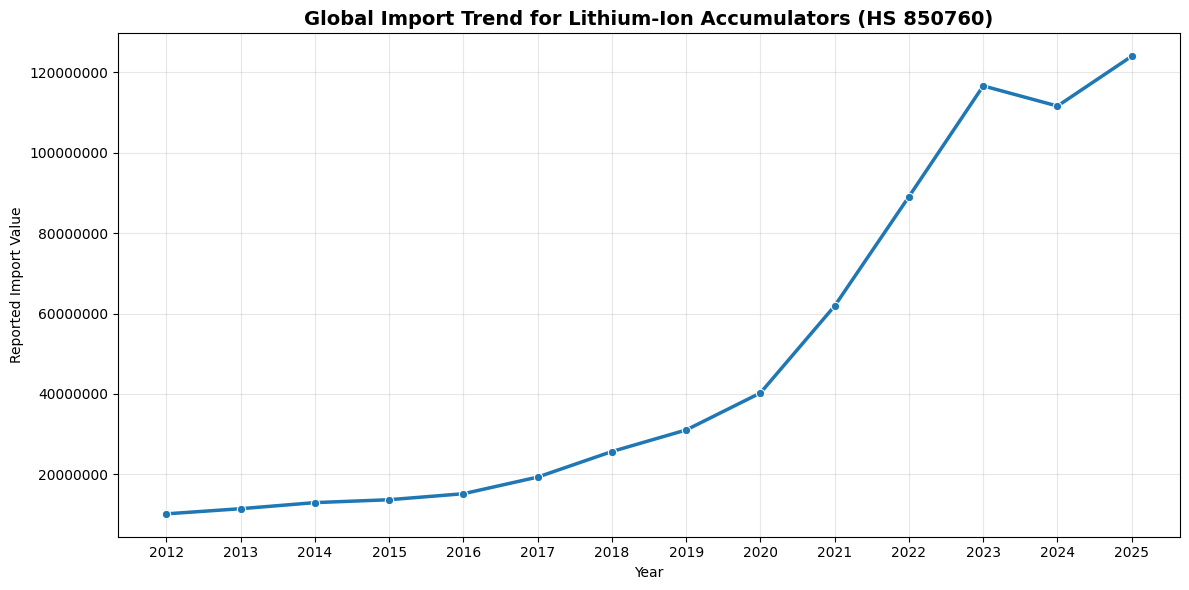

In [16]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=world_trade_df,
    x="Year",
    y="Import Value",
    marker="o",
    linewidth=2.5,
    color="#1f77b4"
)

plt.title(
    "Global Import Trend for Lithium-Ion Accumulators (HS 850760)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Reported Import Value")
plt.xticks(world_trade_df["Year"])
plt.ticklabel_format(style="plain", axis="y")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
world_trade_growth = world_trade_df.copy()

world_trade_growth["Annual Growth (%)"] = (
    world_trade_growth["Import Value"]
    .pct_change(fill_method=None)
    .mul(100)
)

start_year = world_trade_growth["Year"].min()
end_year = world_trade_growth["Year"].max()

start_value = world_trade_growth.loc[
    world_trade_growth["Year"] == start_year,
    "Import Value"
].iloc[0]

end_value = world_trade_growth.loc[
    world_trade_growth["Year"] == end_year,
    "Import Value"
].iloc[0]

number_of_periods = end_year - start_year

cagr = (
    (end_value / start_value) ** (1 / number_of_periods) - 1
) * 100

display(
    world_trade_growth[
        ["Year", "Import Value", "Annual Growth (%)"]
    ].round(2)
)

print(
    f"\nGlobal import CAGR ({start_year}-{end_year}): "
    f"{cagr:.2f}%"
)

,Year,Import Value,Annual Growth (%)
4546,2012,10170016.0,NaN
4547,2013,11449019.0,12.58
4548,2014,12961890.0,13.21
4549,2015,13682466.0,5.56
4550,2016,15174344.0,10.90
4551,2017,19312728.0,27.27
4552,2018,25672564.0,32.93
4553,2019,31038055.0,20.90
4554,2020,40249915.0,29.68
4555,2021,61900015.0,53.79



Global import CAGR (2012-2025): 21.21%


### **3.1.3. Largest Import Markets**

Germany was the largest reported import market for lithium-ion accumulators in 2025, with an import value of 22,974,328, followed by the United States with 20,084,555. Together, these two markets accounted for approximately 34.7% of the reported global import value. A substantial gap appears after the two leading markets, with Viet Nam and the Republic of Korea recording approximately 4.98 million and 4.95 million, respectively. The results indicate that current demand is strongly concentrated in Germany and the United States, while several European and Asian economies form a more diversified group of secondary markets.

Latest trade year: 2025


,Importers,Import Value
1659,Germany,22974328.0
4379,United States of America,20084555.0
4479,Viet Nam,4978530.0
2259,"Korea, Republic of",4946958.0
239,Australia,4783142.0
1159,Czech Republic,4563440.0
2719,Mexico,4280155.0
1979,India,4092112.0
2959,Netherlands,3445254.0
1519,France,3149857.0


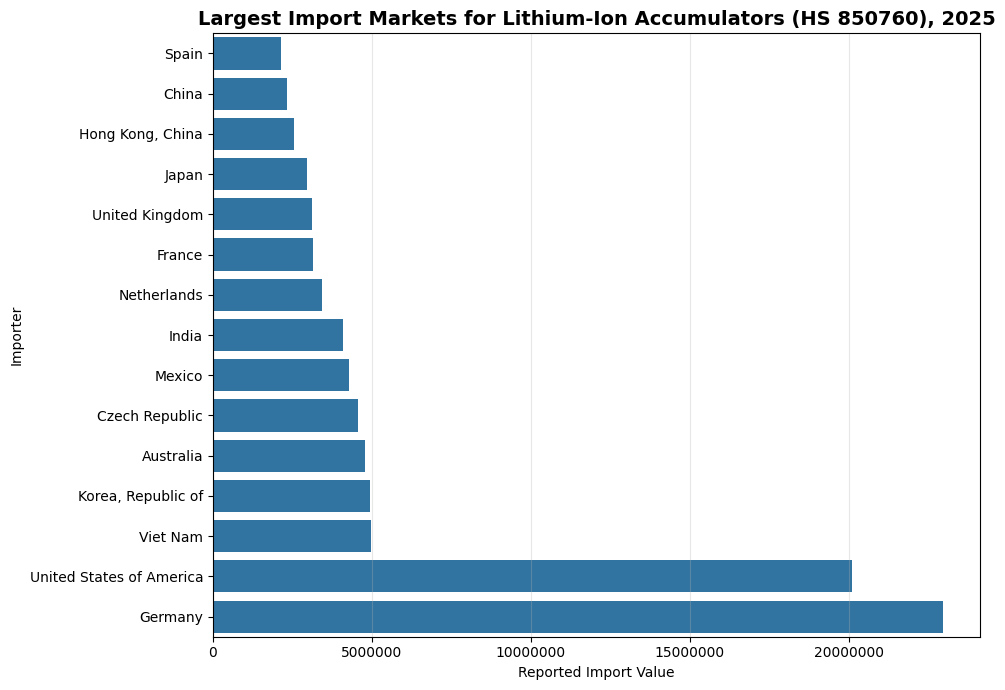

In [18]:
latest_trade_year = country_trade_df["Year"].max()

top_importers_latest_year = (
    country_trade_df[
        (country_trade_df["Year"] == latest_trade_year)
        & (country_trade_df["Import Value"].notna())
        & (country_trade_df["Import Value"] > 0)
    ]
    .nlargest(15, "Import Value")
    .sort_values("Import Value", ascending=True)
)

print(f"Latest trade year: {latest_trade_year}")

display(
    top_importers_latest_year[
        ["Importers", "Import Value"]
    ].sort_values("Import Value", ascending=False)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_importers_latest_year,
    x="Import Value",
    y="Importers",
    color="#1f77b4"
)

plt.title(
    f"Largest Import Markets for Lithium-Ion Accumulators (HS 850760), {latest_trade_year}",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Reported Import Value")
plt.ylabel("Importer")
plt.ticklabel_format(style="plain", axis="x")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### **3.1.4. Import Growth by Country**

To reduce distortions caused by very small initial import values, the growth comparison was restricted to countries with positive import values in both 2012 and 2025, at least 10 years of positive observations, and a 2025 import value within the upper quartile of eligible markets. Among the 33 countries meeting these criteria, Saudi Arabia recorded the highest CAGR at 73.92%, followed by Bulgaria at 59.96% and Slovakia at 50.33%. The United Arab Emirates and Mexico also demonstrated strong annualised growth of 48.07% and 44.43%, respectively. Germany combined a comparatively high CAGR of 32.97% with the largest 2025 import value, making it particularly notable in terms of both market size and long-term growth.

In [19]:
start_year = ANALYSIS_START_YEAR
end_year = ANALYSIS_END_YEAR
number_of_periods = end_year - start_year

country_growth = (
    country_trade_df[
        country_trade_df["Year"].isin([start_year, end_year])
    ]
    .pivot(index="Importers", columns="Year", values="Import Value")
    .dropna(subset=[start_year, end_year])
)

# CAGR requires positive values in both the first and final year.
country_growth = country_growth[
    (country_growth[start_year] > 0)
    & (country_growth[end_year] > 0)
].copy()

country_growth["Absolute Growth"] = (
    country_growth[end_year] - country_growth[start_year]
)

country_growth["Total Growth (%)"] = (
    (country_growth[end_year] / country_growth[start_year] - 1) * 100
)

country_growth["CAGR (%)"] = (
    (country_growth[end_year] / country_growth[start_year])
    ** (1 / number_of_periods) - 1
) * 100

country_growth = country_growth.reset_index().rename(
    columns={
        start_year: f"Import Value {start_year}",
        end_year: f"Import Value {end_year}"
    }
)

print("Countries with valid positive values in both years:", len(country_growth))

display(
    country_growth.nlargest(15, "CAGR (%)")[
        [
            "Importers",
            f"Import Value {start_year}",
            f"Import Value {end_year}",
            "Absolute Growth",
            "CAGR (%)"
        ]
    ].round(2)
)

Countries with valid positive values in both years: 132


Year,Importers,Import Value 2012,Import Value 2025,Absolute Growth,CAGR (%)
87,Pakistan,3.0,171709.0,171706.0,132.26
110,Sudan,1.0,26069.0,26068.0,118.63
130,Yemen,6.0,83079.0,83073.0,108.24
16,Cambodia,6.0,67227.0,67221.0,104.88
32,Djibouti,1.0,9404.0,9403.0,102.13
102,Sierra Leone,4.0,22043.0,22039.0,93.99
126,Uzbekistan,99.0,498420.0,498321.0,92.65
36,Eritrea,2.0,8597.0,8595.0,90.32
121,Uganda,11.0,35098.0,35087.0,86.01
62,Jordan,40.0,99392.0,99352.0,82.46


In [20]:
latest_value_column = f"Import Value {end_year}"
minimum_latest_value = country_growth[latest_value_column].quantile(0.75)

meaningful_growth = (
    country_growth
    .merge(
        country_coverage[["Importers", "Positive_Import_Years"]],
        on="Importers",
        how="left"
    )
    .query(
        "Positive_Import_Years >= 10 "
        "and `Import Value 2025` >= @minimum_latest_value"
    )
    .sort_values("CAGR (%)", ascending=False)
)

print(f"Minimum 2025 import value (75th percentile): {minimum_latest_value:,.0f}")
print("Number of substantial markets:", len(meaningful_growth))

display(
    meaningful_growth[
        [
            "Importers",
            "Import Value 2012",
            "Import Value 2025",
            "Positive_Import_Years",
            "Absolute Growth",
            "CAGR (%)"
        ]
    ].head(15).round(2)
)

Minimum 2025 import value (75th percentile): 517,827
Number of substantial markets: 33


,Importers,Import Value 2012,Import Value 2025,Positive_Import_Years,Absolute Growth,CAGR (%)
99,Saudi Arabia,1301.0,1732918.0,14,1731617.0,73.92
15,Bulgaria,2045.0,917827.0,14,915782.0,59.96
105,Slovakia,7119.0,1425097.0,14,1417978.0,50.33
122,United Arab Emirates,3898.0,641152.0,14,637254.0,48.07
78,Mexico,35970.0,4280155.0,14,4244185.0,44.43
95,Romania,12666.0,1145465.0,14,1132799.0,41.41
30,Czech Republic,53174.0,4563440.0,14,4510266.0,40.84
4,Australia,85045.0,4783142.0,14,4698097.0,36.34
41,Finland,17521.0,930189.0,14,912668.0,35.74
60,Italy,30926.0,1526494.0,14,1495568.0,34.98


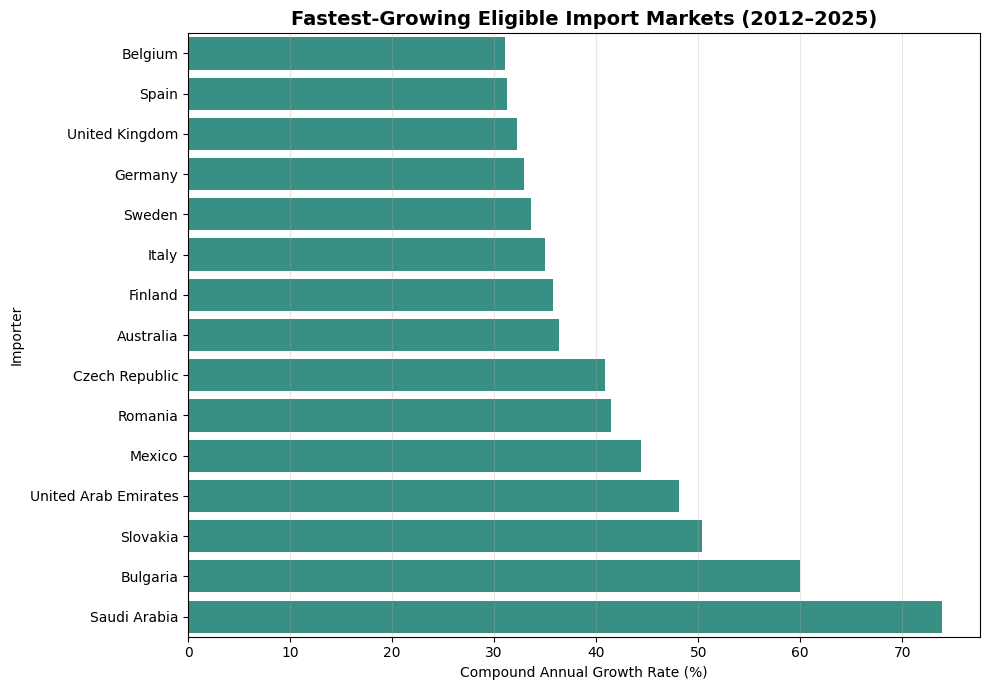

In [22]:
top_growth_markets = (
    meaningful_growth
    .head(15)
    .sort_values("CAGR (%)", ascending=True)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_growth_markets,
    x="CAGR (%)",
    y="Importers",
    color="#2a9d8f"
)

plt.title(
    f"Fastest-Growing Eligible Import Markets ({start_year}–{end_year})",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Compound Annual Growth Rate (%)")
plt.ylabel("Importer")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## **3.2. Global Trade Alert Data Analysis**

### **3.2.1. Dataset Structure and Coverage**

The Global Trade Alert dataset contains 1,605 intervention records and 19 variables. Most descriptive and classification fields are complete, while the affected jurisdiction is missing for 224 records and the implementation date is unavailable for 161 records. Removal dates are absent for 1,154 interventions, which may indicate that many measures remain in force or have no recorded removal date rather than representing a conventional data-quality issue. Recorded implementation dates range from 2012 to 2026, with 176 interventions scheduled after the 2025 trade-data endpoint. These future-dated records must therefore be excluded from historical modelling to prevent temporal data leakage.

In [23]:
gta_analysis_df = gta_df.copy()

date_columns = [
    "Date Announced",
    "Date Implemented",
    "Date Removed"
]

for column in date_columns:
    gta_analysis_df[column] = pd.to_datetime(
        gta_analysis_df[column],
        errors="coerce"
    )

gta_column_overview = pd.DataFrame({
    "Data Type": gta_analysis_df.dtypes.astype(str),
    "Non-Null Values": gta_analysis_df.notna().sum(),
    "Missing Values": gta_analysis_df.isna().sum(),
    "Unique Values": gta_analysis_df.nunique(dropna=True)
})

display(gta_column_overview)

print(
    "Implementation date range:",
    gta_analysis_df["Date Implemented"].min(),
    "-",
    gta_analysis_df["Date Implemented"].max()
)

future_interventions = (
    gta_analysis_df["Date Implemented"].dt.year
    > ANALYSIS_END_YEAR
).sum()

print(
    f"Interventions implemented after {ANALYSIS_END_YEAR}:",
    future_interventions
)

,Data Type,Non-Null Values,Missing Values,Unique Values
Intervention ID,int64,1605,0,1605
Intervention URL,object,1605,0,1605
State Act ID,int64,1605,0,1272
State Act URL,object,1605,0,1272
State Act Title,object,1605,0,1267
GTA Evaluation,object,1605,0,3
Implementing Jurisdictions,object,1605,0,107
Implementation Level,object,1605,0,5
Eligible Firm,object,1605,0,7
Intervention Type,object,1605,0,56


Implementation date range: 2012-01-01 00:00:00 - 2026-11-10 00:00:00
Interventions implemented after 2025: 176


### **3.2.2. Intervention Evaluation Distribution**

Red interventions dominate the dataset, accounting for 1,159 records (72.21%), compared with 323 Green interventions (20.12%) and 123 Amber interventions (7.66%). This distribution indicates that the policy environment captured for lithium-ion accumulators is predominantly associated with trade-restrictive or discriminatory measures, while liberalising measures represent a considerably smaller share. The strong imbalance between evaluation categories should be preserved as meaningful policy information, but it must also be considered when constructing policy-based features and interpreting model results.

,GTA Evaluation,Number of Interventions,Percentage (%)
0,Red,1159,72.21
1,Green,323,20.12
2,Amber,123,7.66


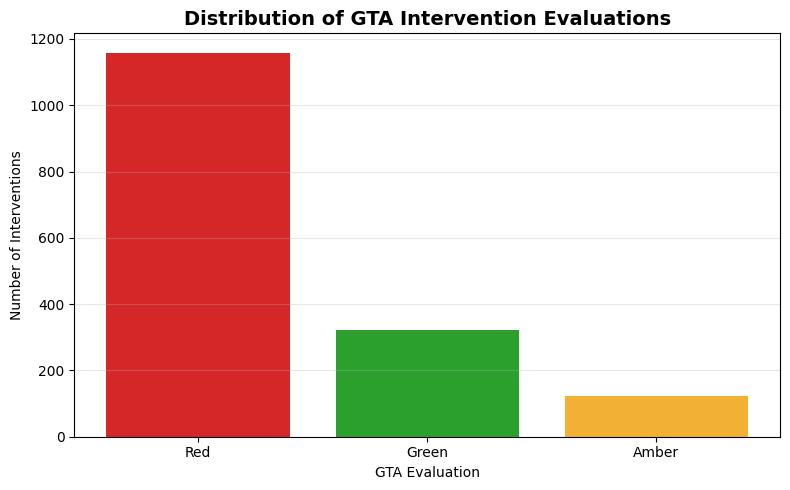

In [24]:
evaluation_order = ["Red", "Green", "Amber"]

evaluation_summary = (
    gta_analysis_df["GTA Evaluation"]
    .value_counts()
    .reindex(evaluation_order)
    .rename_axis("GTA Evaluation")
    .reset_index(name="Number of Interventions")
)

evaluation_summary["Percentage (%)"] = (
    evaluation_summary["Number of Interventions"]
    / evaluation_summary["Number of Interventions"].sum()
    * 100
).round(2)

display(evaluation_summary)

plt.figure(figsize=(8, 5))

plt.bar(
    evaluation_summary["GTA Evaluation"],
    evaluation_summary["Number of Interventions"],
    color=["#d62728", "#2ca02c", "#f2b134"]
)

plt.title(
    "Distribution of GTA Intervention Evaluations",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("GTA Evaluation")
plt.ylabel("Number of Interventions")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### **3.2.3. Most Frequent Intervention Types**

Import tariffs are the most frequently recorded intervention type, representing 352 interventions (21.93%), followed by financial grants with 297 records (18.50%). Together, these two policy instruments account for 40.43% of all interventions. Other prominent measures include unspecified state aid, state loans, export bans and export licensing requirements. The results show that the policy environment combines border measures with a broad range of domestic financial-support instruments. Since an intervention type does not independently indicate whether a measure is restrictive or liberalising, these categories should subsequently be interpreted together with their GTA Evaluation classifications.

,Intervention Type,Number of Interventions,Percentage (%)
0,Import tariff,352,21.93
1,Financial grant,297,18.50
2,"State aid, unspecified",129,8.04
3,State loan,93,5.79
4,Export ban,82,5.11
5,Export licensing requirement,78,4.86
6,Financial investment support,60,3.74
7,Tax or social insurance relief,57,3.55
8,Trade finance,56,3.49
9,Loan guarantee,31,1.93


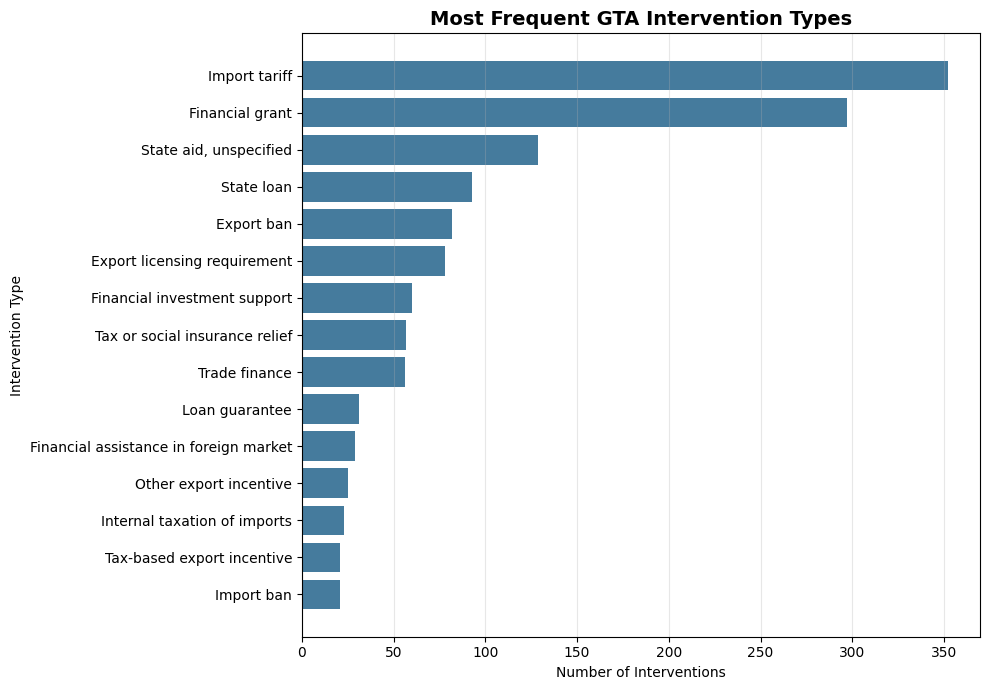

In [25]:
intervention_type_summary = (
    gta_analysis_df["Intervention Type"]
    .value_counts()
    .head(15)
    .rename_axis("Intervention Type")
    .reset_index(name="Number of Interventions")
)

intervention_type_summary["Percentage (%)"] = (
    intervention_type_summary["Number of Interventions"]
    / len(gta_analysis_df)
    * 100
).round(2)

display(intervention_type_summary)

plot_data = intervention_type_summary.sort_values(
    "Number of Interventions",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["Intervention Type"],
    plot_data["Number of Interventions"],
    color="#457b9d"
)

plt.title(
    "Most Frequent GTA Intervention Types",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Number of Interventions")
plt.ylabel("Intervention Type")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### **3.2.4. Intervention Trends Over Time**

The number of newly implemented trade interventions remained relatively low and stable between 2012 and 2019, before beginning to rise in 2020. A clear shift occurred in 2022, when the annual count increased from 68 to 198 interventions. Activity reached its highest level in 2023 with 257 newly implemented measures, declined to 183 in 2024, and rose again to 242 in 2025. Red interventions account for most of this recent increase, suggesting that the lithium-ion battery market has faced a more active and predominantly restrictive policy environment since 2022. These figures represent new interventions implemented each year rather than the cumulative number of measures remaining in force.

GTA Evaluation,Red,Green,Amber,Total
Implementation Year,,,,
2012,14,17,0,31
2013,22,7,2,31
2014,13,6,1,20
2015,23,11,0,34
2016,12,11,1,24
2017,26,10,0,36
2018,26,9,0,35
2019,33,7,0,40
2020,42,26,1,69


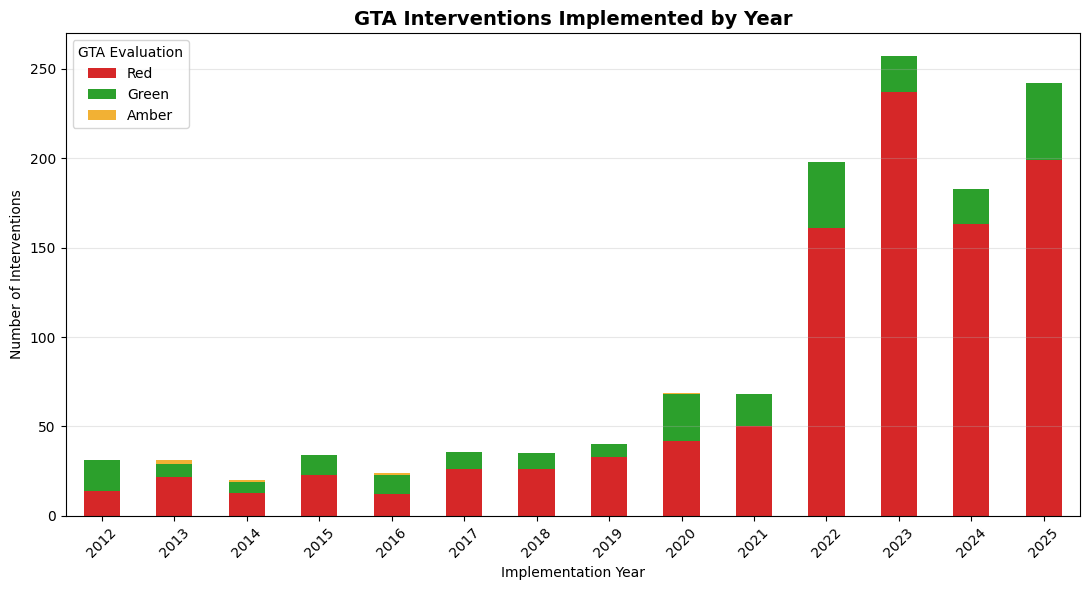

In [26]:
historical_gta_df = gta_analysis_df[
    gta_analysis_df["Date Implemented"].dt.year.between(
        ANALYSIS_START_YEAR,
        ANALYSIS_END_YEAR
    )
].copy()

historical_gta_df["Implementation Year"] = (
    historical_gta_df["Date Implemented"].dt.year.astype(int)
)

annual_interventions = (
    historical_gta_df
    .groupby(["Implementation Year", "GTA Evaluation"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Red", "Green", "Amber"], fill_value=0)
)

annual_interventions["Total"] = annual_interventions.sum(axis=1)

display(annual_interventions)

annual_interventions[["Red", "Green", "Amber"]].plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=["#d62728", "#2ca02c", "#f2b134"]
)

plt.title(
    "GTA Interventions Implemented by Year",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Implementation Year")
plt.ylabel("Number of Interventions")
plt.xticks(rotation=45)
plt.legend(title="GTA Evaluation")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### **3.2.5. Geographic Distribution of Interventions**

The United States and China implemented the largest numbers of trade interventions during the 2012–2025 period, with 181 and 174 records, respectively. France, Italy and Germany form the next group, followed by several other European countries with relatively similar intervention counts. Part of this European concentration reflects multi-jurisdiction measures, where the same intervention applies to several participating countries. These records were therefore separated by jurisdiction and counted once for each relevant country. The results show that policy activity is concentrated in major global markets, although country-level counts should be interpreted alongside the shared nature of some regional measures.

,Implementing Jurisdiction,Number of Interventions
0,United States of America,181
1,China,174
2,Italy,114
3,France,114
4,Germany,108
5,Hungary,96
6,Poland,95
7,Spain,95
8,Sweden,91
9,Finland,91


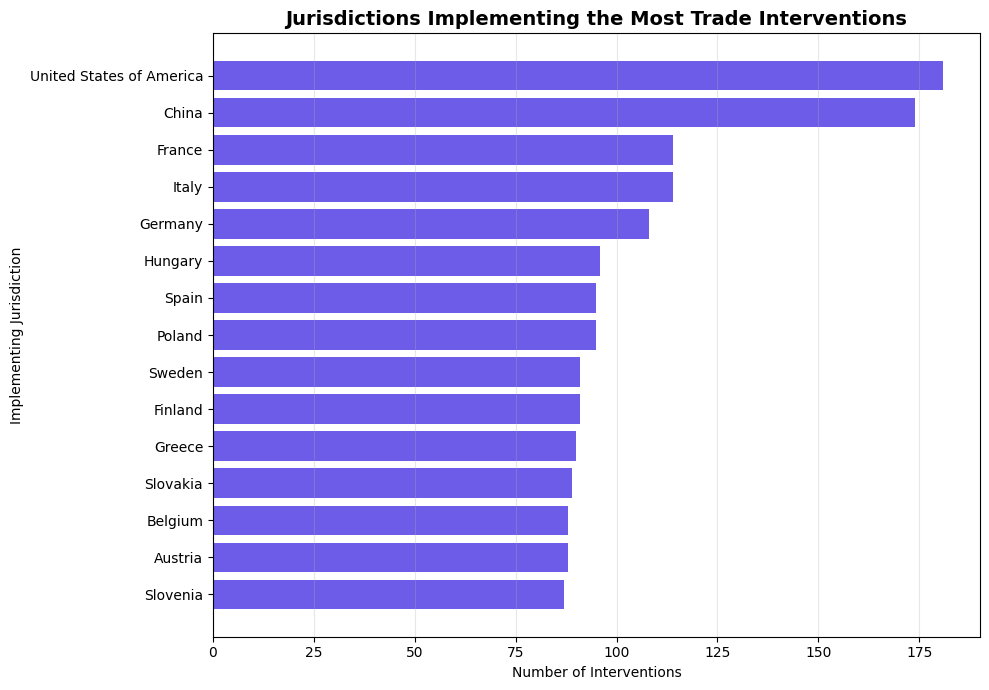

In [28]:
jurisdiction_long_df = (
    historical_gta_df[
        ["Intervention ID", "Implementing Jurisdictions"]
    ]
    .assign(
        Implementing_Jurisdiction=lambda df:
        df["Implementing Jurisdictions"].str.split(",")
    )
    .explode("Implementing_Jurisdiction")
)

jurisdiction_long_df["Implementing_Jurisdiction"] = (
    jurisdiction_long_df["Implementing_Jurisdiction"]
    .str.strip()
)

# Avoid counting the same intervention twice for the same jurisdiction.
jurisdiction_long_df = jurisdiction_long_df.drop_duplicates(
    subset=["Intervention ID", "Implementing_Jurisdiction"]
)

jurisdiction_summary = (
    jurisdiction_long_df["Implementing_Jurisdiction"]
    .value_counts()
    .head(15)
    .rename_axis("Implementing Jurisdiction")
    .reset_index(name="Number of Interventions")
)

display(jurisdiction_summary)

plot_data = jurisdiction_summary.sort_values(
    "Number of Interventions",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["Implementing Jurisdiction"],
    plot_data["Number of Interventions"],
    color="#6c5ce7"
)

plt.title(
    "Jurisdictions Implementing the Most Trade Interventions",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Number of Interventions")
plt.ylabel("Implementing Jurisdiction")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### **3.2.6. Policy Direction by Jurisdiction**

Red interventions form the largest category in each of the ten most active jurisdictions, confirming that the overall dominance of restrictive measures is not driven by a single country. China and the United States show the highest numbers of Red interventions, while Green measures make up a visibly smaller part of their policy activity. European jurisdictions display similar Red–Green profiles, partly because several interventions apply jointly across multiple countries. Amber measures are rare throughout the group. These differences suggest that country-level policy features should distinguish between restrictive and liberalising interventions rather than relying only on the total number of measures.

GTA Evaluation,Red,Green,Amber
Implementing Jurisdiction,,,
United States of America,159,22,0
China,161,13,0
Italy,92,21,1
France,92,21,1
Germany,86,21,1
Hungary,74,21,1
Poland,73,21,1
Spain,73,21,1
Sweden,69,21,1


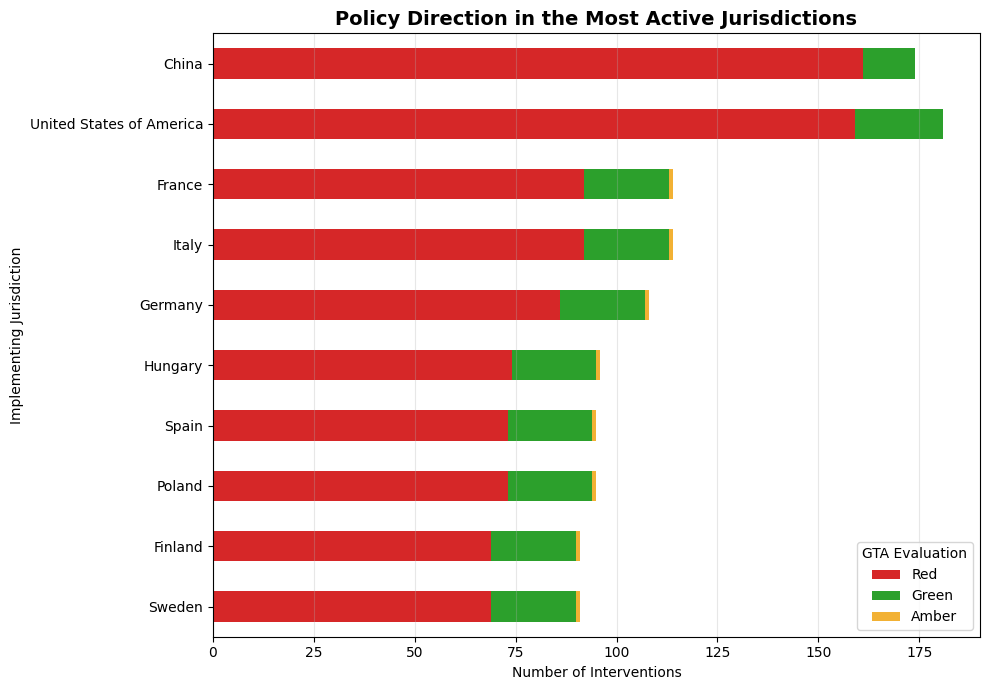

In [29]:
jurisdiction_evaluation_df = jurisdiction_long_df.merge(
    historical_gta_df[
        ["Intervention ID", "GTA Evaluation"]
    ],
    on="Intervention ID",
    how="left"
)

top_jurisdictions = (
    jurisdiction_summary
    .head(10)["Implementing Jurisdiction"]
)

jurisdiction_evaluation = pd.crosstab(
    jurisdiction_evaluation_df["Implementing_Jurisdiction"],
    jurisdiction_evaluation_df["GTA Evaluation"]
).reindex(
    index=top_jurisdictions,
    columns=["Red", "Green", "Amber"],
    fill_value=0
)

display(jurisdiction_evaluation)

jurisdiction_evaluation.sort_values(
    by=["Red", "Green", "Amber"]
).plot(
    kind="barh",
    stacked=True,
    figsize=(10, 7),
    color=["#d62728", "#2ca02c", "#f2b134"]
)

plt.title(
    "Policy Direction in the Most Active Jurisdictions",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Number of Interventions")
plt.ylabel("Implementing Jurisdiction")
plt.legend(title="GTA Evaluation")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### **3.2.7. Current Status of Interventions**

Of the 1,605 interventions in the dataset, 1,155 (71.96%) are currently recorded as being in force. Red measures appear particularly persistent, with 948 of 1,159 interventions still active, compared with 203 of 323 Green interventions. In contrast, only 4 of the 123 Amber interventions are currently in force. This pattern shows that current policy exposure cannot be represented adequately by historical intervention counts alone. The model should also account for whether a measure remains active in each country and year, especially because a large majority of restrictive interventions continue to apply.

,Status,Number of Interventions,Percentage (%)
0,In Force,1155,71.96
1,Not In Force,450,28.04


Is In Force,In Force,Not In Force
GTA Evaluation,,
Red,948,211
Green,203,120
Amber,4,119


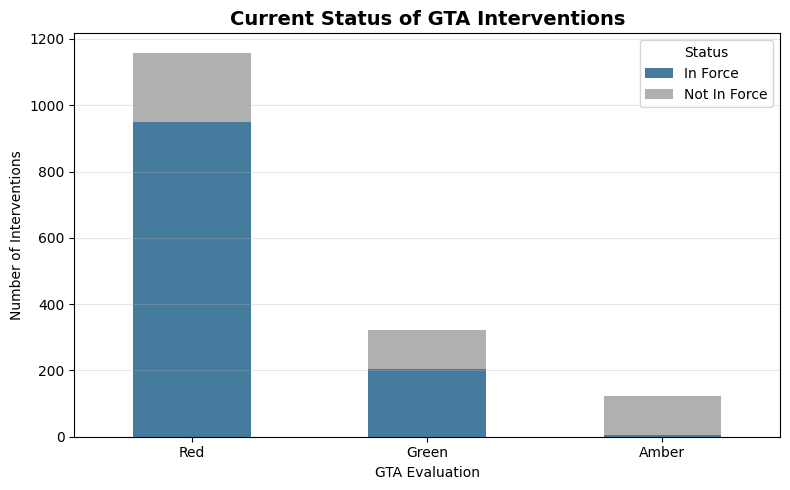

In [30]:
status_summary = (
    gta_analysis_df["Is In Force"]
    .map({1: "In Force", 0: "Not In Force"})
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Number of Interventions")
)

status_summary["Percentage (%)"] = (
    status_summary["Number of Interventions"]
    / len(gta_analysis_df)
    * 100
).round(2)

display(status_summary)

evaluation_status = pd.crosstab(
    gta_analysis_df["GTA Evaluation"],
    gta_analysis_df["Is In Force"].map({
        1: "In Force",
        0: "Not In Force"
    })
).reindex(
    index=["Red", "Green", "Amber"],
    columns=["In Force", "Not In Force"],
    fill_value=0
)

display(evaluation_status)

evaluation_status.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["#457b9d", "#b0b0b0"]
)

plt.title(
    "Current Status of GTA Interventions",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("GTA Evaluation")
plt.ylabel("Number of Interventions")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## **3.3. Initial Findings**

The exploratory analysis shows a market that is growing quickly but is also becoming more exposed to policy intervention. Reported global imports of lithium-ion accumulators increased substantially between 2012 and 2025, with Germany and the United States emerging as the largest markets in the latest year. Several other countries, including Saudi Arabia, Bulgaria and Slovakia, recorded strong long-term growth after minimum market-size and data-coverage conditions were applied. This suggests that market size and growth should be considered together, as the largest markets are not always the fastest-growing ones.

At the same time, trade-policy activity increased sharply after 2021 and is dominated by Red interventions. Most recorded measures remain in force, while import tariffs and financial support measures are among the most common policy instruments. The United States and China are the most active individual jurisdictions, although shared regional measures also contribute to high counts across European countries. Overall, these findings support the use of two forecasting approaches: a baseline model based on historical trade patterns and a policy-enriched model that tests whether country-level intervention information improves predictive performance.

# **4. Data Cleaning and Preprocessing**

## **4.1. Trade Map Data Cleaning**

The Trade Map data was cleaned while keeping the distinction between missing values and reported zero imports. Country names were standardized by removing unnecessary spaces, and import values were converted to numeric format. No duplicate country-year records or negative import values were identified. To ensure that each country had enough historical information for forecasting, importers with fewer than 10 reported years were excluded, reducing the sample from 230 to 212 importers. The remaining 29 missing observations represented only 0.98% of the filtered data and were removed rather than imputed. All 289 reported zero values were retained because they may reflect genuine periods of no or very low recorded trade. The final cleaned Trade Map dataset contains 2,939 country-year observations.

In [31]:
trade_clean_df = country_trade_df.copy()

trade_clean_df["Importers"] = (
    trade_clean_df["Importers"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

trade_clean_df["Import Value"] = pd.to_numeric(
    trade_clean_df["Import Value"],
    errors="coerce"
)

duplicate_country_years = trade_clean_df.duplicated(
    subset=["Importers", "Year"]
).sum()

negative_import_values = (
    trade_clean_df["Import Value"] < 0
).sum()

print("Trade Map cleaning check")
print("------------------------")
print("Rows:", len(trade_clean_df))
print("Unique importers:", trade_clean_df["Importers"].nunique())
print("Duplicate importer-year rows:", duplicate_country_years)
print("Missing import values:", trade_clean_df["Import Value"].isna().sum())
print("Zero import values:", trade_clean_df["Import Value"].eq(0).sum())
print("Negative import values:", negative_import_values)

Trade Map cleaning check
------------------------
Rows: 3220
Unique importers: 230
Duplicate importer-year rows: 0
Missing import values: 198
Zero import values: 289
Negative import values: 0


In [32]:
MIN_REPORTED_YEARS = 10

reported_years_by_importer = (
    trade_clean_df
    .groupby("Importers")["Import Value"]
    .apply(lambda values: values.notna().sum())
)

eligible_importers = reported_years_by_importer[
    reported_years_by_importer >= MIN_REPORTED_YEARS
].index

excluded_importers = reported_years_by_importer[
    reported_years_by_importer < MIN_REPORTED_YEARS
].index

trade_clean_df["Import Value Missing"] = (
    trade_clean_df["Import Value"].isna().astype(int)
)

trade_clean_df = trade_clean_df[
    trade_clean_df["Importers"].isin(eligible_importers)
].copy()

print("Minimum reported years required:", MIN_REPORTED_YEARS)
print("Eligible importers:", len(eligible_importers))
print("Excluded importers:", len(excluded_importers))
print("Remaining rows:", len(trade_clean_df))
print("Remaining missing values:", trade_clean_df["Import Value"].isna().sum())
print("Remaining zero values:", trade_clean_df["Import Value"].eq(0).sum())

Minimum reported years required: 10
Eligible importers: 212
Excluded importers: 18
Remaining rows: 2968
Remaining missing values: 29
Remaining zero values: 289


In [33]:
missing_share = (
    trade_clean_df["Import Value"].isna().mean() * 100
)

print(f"Missing value percentage before removal: {missing_share:.2f}%")

trade_clean_df = (
    trade_clean_df
    .dropna(subset=["Import Value"])
    .sort_values(["Importers", "Year"])
    .reset_index(drop=True)
)

print("Final Trade Map rows:", len(trade_clean_df))
print("Final number of importers:", trade_clean_df["Importers"].nunique())
print("Remaining missing values:", trade_clean_df["Import Value"].isna().sum())
print("Remaining zero values:", trade_clean_df["Import Value"].eq(0).sum())

Missing value percentage before removal: 0.98%
Final Trade Map rows: 2939
Final number of importers: 212
Remaining missing values: 0
Remaining zero values: 289


In [34]:
trade_clean_df = trade_clean_df.drop(columns=["Import Value Missing"])

## **4.2. GTA Data Cleaning**

The Global Trade Alert data was restricted to interventions implemented between 2012 and 2025 so that its time coverage matched the Trade Map dataset. Records without an implementation date and interventions scheduled after 2025 were excluded, preventing future policy information from entering the historical analysis. Text fields were standardized, and no duplicate intervention IDs were found in the filtered source data.

Some interventions applied to several jurisdictions listed within a single cell. These entries were separated so that each intervention-country combination formed its own row. Country names were then aligned with the naming conventions used in Trade Map, including differences such as “Vietnam” and “Viet Nam”. One Belize record could not be matched because Belize did not meet the minimum Trade Map coverage requirement and was therefore excluded. The final cleaned GTA dataset contains 3,496 intervention-country rows representing 1,267 unique interventions across 93 matched countries, with no duplicate intervention-country combinations or missing evaluation and implementation-year values.

In [35]:
gta_clean_df = gta_analysis_df.copy()

text_columns = [
    "GTA Evaluation",
    "Implementing Jurisdictions",
    "Implementation Level",
    "Eligible Firm",
    "Intervention Type"
]

for column in text_columns:
    gta_clean_df[column] = (
        gta_clean_df[column]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

gta_clean_df = gta_clean_df[
    gta_clean_df["Date Implemented"].notna()
    & gta_clean_df["Date Implemented"].dt.year.between(
        ANALYSIS_START_YEAR,
        ANALYSIS_END_YEAR
    )
].copy()

gta_clean_df["Implementation Year"] = (
    gta_clean_df["Date Implemented"].dt.year.astype(int)
)

gta_clean_df = (
    gta_clean_df
    .drop_duplicates(subset=["Intervention ID"])
    .sort_values(["Implementation Year", "Intervention ID"])
    .reset_index(drop=True)
)

print("Final intervention records:", len(gta_clean_df))
print(
    "Implementation period:",
    gta_clean_df["Implementation Year"].min(),
    "-",
    gta_clean_df["Implementation Year"].max()
)
print(
    "Duplicate intervention IDs:",
    gta_clean_df["Intervention ID"].duplicated().sum()
)
print(
    "Missing implementing jurisdictions:",
    gta_clean_df["Implementing Jurisdictions"].isna().sum()
)
print(
    "Missing GTA evaluations:",
    gta_clean_df["GTA Evaluation"].isna().sum()
)

Final intervention records: 1268
Implementation period: 2012 - 2025
Duplicate intervention IDs: 0
Missing implementing jurisdictions: 0
Missing GTA evaluations: 0


In [36]:
gta_country_df = gta_clean_df.copy()

gta_country_df["Implementing Jurisdiction"] = (
    gta_country_df["Implementing Jurisdictions"]
    .str.split(",")
)

gta_country_df = gta_country_df.explode(
    "Implementing Jurisdiction"
)

gta_country_df["Implementing Jurisdiction"] = (
    gta_country_df["Implementing Jurisdiction"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

gta_country_df = (
    gta_country_df
    .dropna(subset=["Implementing Jurisdiction"])
    .drop_duplicates(
        subset=["Intervention ID", "Implementing Jurisdiction"]
    )
    .reset_index(drop=True)
)

trade_country_names = set(trade_clean_df["Importers"])
gta_country_names = set(
    gta_country_df["Implementing Jurisdiction"]
)

matched_country_names = (
    trade_country_names & gta_country_names
)

unmatched_gta_names = sorted(
    gta_country_names - trade_country_names
)

print("Original intervention records:", len(gta_clean_df))
print("Country-level intervention rows:", len(gta_country_df))
print("Unique GTA jurisdictions:", len(gta_country_names))
print("Exact country-name matches:", len(matched_country_names))
print("Unmatched GTA jurisdiction names:", len(unmatched_gta_names))

display(
    pd.DataFrame({
        "Unmatched GTA Jurisdiction": unmatched_gta_names
    })
)

Original intervention records: 1268
Country-level intervention rows: 3497
Unique GTA jurisdictions: 94
Exact country-name matches: 83
Unmatched GTA jurisdiction names: 11


,Unmatched GTA Jurisdiction
0,Belize
1,Cape Verde
2,Czechia
3,Hong Kong
4,Republic of Korea
5,Republic of Moldova
6,Russia
7,Tanzania
8,Turkiye
9,Venezuela


In [37]:
country_name_mapping = {
    "Cape Verde": "Cabo Verde",
    "Czechia": "Czech Republic",
    "Hong Kong": "Hong Kong, China",
    "Republic of Korea": "Korea, Republic of",
    "Republic of Moldova": "Moldova, Republic of",
    "Russia": "Russian Federation",
    "Tanzania": "Tanzania, United Republic of",
    "Turkiye": "Türkiye",
    "Venezuela": "Venezuela, Bolivarian Republic of",
    "Vietnam": "Viet Nam"
}

gta_country_df["Country"] = (
    gta_country_df["Implementing Jurisdiction"]
    .replace(country_name_mapping)
)

gta_country_df["Matches Trade Map"] = (
    gta_country_df["Country"].isin(trade_country_names)
)

unmatched_after_mapping = (
    gta_country_df.loc[
        ~gta_country_df["Matches Trade Map"],
        "Country"
    ]
    .value_counts()
    .rename_axis("Unmatched Country")
    .reset_index(name="Intervention Rows")
)

print(
    "Matched country-level rows:",
    gta_country_df["Matches Trade Map"].sum()
)
print(
    "Unmatched country-level rows:",
    (~gta_country_df["Matches Trade Map"]).sum()
)
print(
    "Unique unmatched countries:",
    unmatched_after_mapping["Unmatched Country"].nunique()
)

display(unmatched_after_mapping)

Matched country-level rows: 3496
Unmatched country-level rows: 1
Unique unmatched countries: 1


,Unmatched Country,Intervention Rows
0,Belize,1


In [38]:
gta_country_clean_df = (
    gta_country_df[
        gta_country_df["Matches Trade Map"]
    ]
    .drop(
        columns=[
            "Matches Trade Map",
            "Implementing Jurisdiction"
        ]
    )
    .sort_values(
        ["Country", "Implementation Year", "Intervention ID"]
    )
    .reset_index(drop=True)
)

print("Final country-level GTA rows:", len(gta_country_clean_df))
print(
    "Unique interventions:",
    gta_country_clean_df["Intervention ID"].nunique()
)
print(
    "Unique matched countries:",
    gta_country_clean_df["Country"].nunique()
)
print(
    "Duplicate intervention-country rows:",
    gta_country_clean_df.duplicated(
        subset=["Intervention ID", "Country"]
    ).sum()
)
print(
    "Missing implementation years:",
    gta_country_clean_df["Implementation Year"].isna().sum()
)
print(
    "Missing GTA evaluations:",
    gta_country_clean_df["GTA Evaluation"].isna().sum()
)

Final country-level GTA rows: 3496
Unique interventions: 1267
Unique matched countries: 93
Duplicate intervention-country rows: 0
Missing implementation years: 0
Missing GTA evaluations: 0


## **4.3. Final Data Quality Check**

The final quality checks confirmed that both cleaned datasets are ready for feature engineering and integration. The Trade Map data contains 2,939 observations across 212 importers, with no missing, duplicate or negative import values. The cleaned GTA data contains 3,496 country-level rows representing 1,267 unique interventions across 93 countries. All intervention-country combinations are unique, the required policy fields are complete, and every retained GTA country matches a country in the cleaned Trade Map dataset. Both datasets are also limited to the same 2012–2025 analysis period.

In [39]:
quality_checks = {
    "Trade Map has no duplicate country-year rows":
        not trade_clean_df.duplicated(
            subset=["Importers", "Year"]
        ).any(),

    "Trade Map has no missing import values":
        trade_clean_df["Import Value"].notna().all(),

    "Trade Map has no negative import values":
        trade_clean_df["Import Value"].ge(0).all(),

    "Trade Map years are within the analysis period":
        trade_clean_df["Year"].between(
            ANALYSIS_START_YEAR,
            ANALYSIS_END_YEAR
        ).all(),

    "GTA has no duplicate intervention-country rows":
        not gta_country_clean_df.duplicated(
            subset=["Intervention ID", "Country"]
        ).any(),

    "GTA has no missing country names":
        gta_country_clean_df["Country"].notna().all(),

    "GTA has no missing evaluation values":
        gta_country_clean_df["GTA Evaluation"].notna().all(),

    "GTA implementation years are within the analysis period":
        gta_country_clean_df["Implementation Year"].between(
            ANALYSIS_START_YEAR,
            ANALYSIS_END_YEAR
        ).all(),

    "All GTA countries exist in the cleaned Trade Map data":
        set(gta_country_clean_df["Country"]).issubset(
            set(trade_clean_df["Importers"])
        )
}

quality_check_df = pd.DataFrame({
    "Quality Check": quality_checks.keys(),
    "Passed": quality_checks.values()
})

quality_check_df["Status"] = quality_check_df["Passed"].map({
    True: "PASS",
    False: "FAIL"
})

display(quality_check_df[["Quality Check", "Status"]])

print("\nFinal cleaned dataset summary")
print("--------------------------------")
print("Trade Map rows:", len(trade_clean_df))
print("Trade Map countries:", trade_clean_df["Importers"].nunique())
print("GTA country-level rows:", len(gta_country_clean_df))
print("GTA unique interventions:", gta_country_clean_df["Intervention ID"].nunique())
print("GTA matched countries:", gta_country_clean_df["Country"].nunique())
print("All quality checks passed:", all(quality_checks.values()))

,Quality Check,Status
0,Trade Map has no duplicate country-year rows,PASS
1,Trade Map has no missing import values,PASS
2,Trade Map has no negative import values,PASS
3,Trade Map years are within the analysis period,PASS
4,GTA has no duplicate intervention-country rows,PASS
5,GTA has no missing country names,PASS
6,GTA has no missing evaluation values,PASS
7,GTA implementation years are within the analysis period,PASS
8,All GTA countries exist in the cleaned Trade Map data,PASS



Final cleaned dataset summary
--------------------------------
Trade Map rows: 2939
Trade Map countries: 212
GTA country-level rows: 3496
GTA unique interventions: 1267
GTA matched countries: 93
All quality checks passed: True


# **5. Feature Engineering and Data Integration**

## **5.1. Trade Features**

A complete country-year panel was created before generating the trade features so that each lag referred to the correct calendar year, even when an observation was missing. The feature set includes the current import value, one- to three-year lags, a three-year rolling mean and standard deviation, and one-year import growth. Import values and lags were also transformed using log1p to reduce the influence of highly skewed values while retaining genuine zero-import observations. Logarithmic growth was used instead of percentage growth because it can represent movements from zero without producing infinite values. The remaining missing feature values occur naturally at the beginning of each country’s time series or around unreported years and will be handled when the final modelling sample is constructed.

In [47]:
country_year_index = pd.MultiIndex.from_product(
    [
        trade_clean_df["Importers"].unique(),
        range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1)
    ],
    names=["Importers", "Year"]
)

trade_features_df = (
    trade_clean_df
    .set_index(["Importers", "Year"])
    .reindex(country_year_index)
    .reset_index()
    .sort_values(["Importers", "Year"])
)

country_groups = trade_features_df.groupby("Importers")[
    "Import Value"
]

trade_features_df["Import Lag 1"] = country_groups.shift(1)
trade_features_df["Import Lag 2"] = country_groups.shift(2)
trade_features_df["Import Lag 3"] = country_groups.shift(3)

trade_features_df["Import Growth (%)"] = (
    (
        trade_features_df["Import Value"]
        / trade_features_df["Import Lag 1"]
        - 1
    ) * 100
).replace([np.inf, -np.inf], np.nan)

trade_features_df["Rolling Mean 3 Years"] = (
    trade_features_df
    .groupby("Importers")["Import Value"]
    .transform(
        lambda values: values
        .rolling(window=3, min_periods=2)
        .mean()
    )
)

trade_features_df["Log Import Value"] = np.log1p(
    trade_features_df["Import Value"]
)

sample_country = "Germany"

display(
    trade_features_df[
        trade_features_df["Importers"] == sample_country
    ][
        [
            "Importers",
            "Year",
            "Import Value",
            "Import Lag 1",
            "Import Lag 2",
            "Import Lag 3",
            "Import Growth (%)",
            "Rolling Mean 3 Years",
            "Log Import Value"
        ]
    ]
)

print("Displayed sample country:", sample_country)
print("Country-year panel rows:", len(trade_features_df))
print("Countries:", trade_features_df["Importers"].nunique())
print(
    "Years:",
    trade_features_df["Year"].min(),
    "-",
    trade_features_df["Year"].max()
)

print("\nMissing values by trade feature:")

display(
    trade_features_df[
        [
            "Import Value",
            "Import Lag 1",
            "Import Lag 2",
            "Import Lag 3",
            "Import Growth (%)",
            "Rolling Mean 3 Years",
            "Log Import Value"
        ]
    ]
    .isna()
    .sum()
    .to_frame("Missing Values")
)

,Importers,Year,Import Value,Import Lag 1,Import Lag 2,Import Lag 3,Import Growth (%),Rolling Mean 3 Years,Log Import Value
1064,Germany,2012,565425.0,NaN,NaN,NaN,NaN,NaN,13.245335
1065,Germany,2013,676968.0,565425.0,NaN,NaN,19.727285,6.211965e+05,13.425381
1066,Germany,2014,1031521.0,676968.0,565425.0,NaN,52.373672,7.579713e+05,13.846546
1067,Germany,2015,1313127.0,1031521.0,676968.0,565425.0,27.300074,1.007205e+06,14.087923
1068,Germany,2016,1614343.0,1313127.0,1031521.0,676968.0,22.938832,1.319664e+06,14.294439
1069,Germany,2017,2247410.0,1614343.0,1313127.0,1031521.0,39.215148,1.724960e+06,14.625289
1070,Germany,2018,2857808.0,2247410.0,1614343.0,1313127.0,27.160064,2.239854e+06,14.865566
1071,Germany,2019,3707772.0,2857808.0,2247410.0,1614343.0,29.741816,2.937663e+06,15.125942
1072,Germany,2020,6406589.0,3707772.0,2857808.0,2247410.0,72.788106,4.324056e+06,15.672838
1073,Germany,2021,10358053.0,6406589.0,3707772.0,2857808.0,61.678125,6.824138e+06,16.153275


Displayed sample country: Germany
Country-year panel rows: 2968
Countries: 212
Years: 2012 - 2025

Missing values by trade feature:


,Missing Values
Import Value,29
Import Lag 1,241
Import Lag 2,453
Import Lag 3,665
Import Growth (%),540
Rolling Mean 3 Years,240
Log Import Value,29


In [48]:
trade_features_df["Log Import Lag 1"] = np.log1p(
    trade_features_df["Import Lag 1"]
)

trade_features_df["Log Import Lag 2"] = np.log1p(
    trade_features_df["Import Lag 2"]
)

trade_features_df["Log Import Lag 3"] = np.log1p(
    trade_features_df["Import Lag 3"]
)

trade_features_df["Log Growth 1Y"] = (
    trade_features_df["Log Import Value"]
    - trade_features_df["Log Import Lag 1"]
)

trade_features_df["Rolling Std 3 Years"] = (
    trade_features_df
    .groupby("Importers")["Import Value"]
    .transform(
        lambda values: values
        .rolling(window=3, min_periods=2)
        .std()
    )
)

trade_features_df = trade_features_df.drop(
    columns=["Import Growth (%)"],
    errors="ignore"
)

sample_country = "Germany"

display(
    trade_features_df[
        trade_features_df["Importers"] == sample_country
    ][
        [
            "Importers",
            "Year",
            "Import Value",
            "Log Import Value",
            "Log Import Lag 1",
            "Log Import Lag 2",
            "Log Import Lag 3",
            "Log Growth 1Y",
            "Rolling Mean 3 Years",
            "Rolling Std 3 Years"
        ]
    ]
)

print("Displayed sample country:", sample_country)
print(
    "Missing Log Growth values:",
    trade_features_df["Log Growth 1Y"].isna().sum()
)

,Importers,Year,Import Value,Log Import Value,Log Import Lag 1,Log Import Lag 2,Log Import Lag 3,Log Growth 1Y,Rolling Mean 3 Years,Rolling Std 3 Years
1064,Germany,2012,565425.0,13.245335,NaN,NaN,NaN,NaN,NaN,NaN
1065,Germany,2013,676968.0,13.425381,13.245335,NaN,NaN,0.180046,6.211965e+05,7.887281e+04
1066,Germany,2014,1031521.0,13.846546,13.425381,13.245335,NaN,0.421165,7.579713e+05,2.433773e+05
1067,Germany,2015,1313127.0,14.087923,13.846546,13.425381,13.245335,0.241377,1.007205e+06,3.187758e+05
1068,Germany,2016,1614343.0,14.294439,14.087923,13.846546,13.425381,0.206517,1.319664e+06,2.914660e+05
1069,Germany,2017,2247410.0,14.625289,14.294439,14.087923,13.846546,0.330850,1.724960e+06,4.768629e+05
1070,Germany,2018,2857808.0,14.865566,14.625289,14.294439,14.087923,0.240276,2.239854e+06,6.217669e+05
1071,Germany,2019,3707772.0,15.125942,14.865566,14.625289,14.294439,0.260376,2.937663e+06,7.334487e+05
1072,Germany,2020,6406589.0,15.672838,15.125942,14.865566,14.625289,0.546896,4.324056e+06,1.852921e+06
1073,Germany,2021,10358053.0,16.153275,15.672838,15.125942,14.865566,0.480437,6.824138e+06,3.344745e+06


Displayed sample country: Germany
Missing Log Growth values: 253


## **5.2. GTA Features**

The policy features were created at the country-year level to capture both new policy activity and the stock of measures already in force. Annual counts were calculated separately for Red, Green and Amber interventions, together with the total number of new measures. Active intervention counts include policies that were in force during at least part of the relevant year, using their implementation and removal dates.

Two net policy scores were also created by subtracting the number of Red interventions from the number of Green interventions. Negative values therefore indicate a stronger restrictive policy balance, while positive values indicate a more liberalising balance. The share of active interventions classified as Red was included as an additional measure of policy direction. The resulting table contains 967 country-year records across 93 countries, with no duplicate keys or missing policy-feature values.

In [49]:
gta_annual_features = (
    gta_country_clean_df
    .groupby(
        ["Country", "Implementation Year", "GTA Evaluation"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=["Red", "Green", "Amber"],
        fill_value=0
    )
    .reset_index()
    .rename(
        columns={
            "Implementation Year": "Year",
            "Red": "New Red Interventions",
            "Green": "New Green Interventions",
            "Amber": "New Amber Interventions"
        }
    )
)

gta_annual_features.columns.name = None

gta_annual_features["New Total Interventions"] = (
    gta_annual_features[
        [
            "New Red Interventions",
            "New Green Interventions",
            "New Amber Interventions"
        ]
    ].sum(axis=1)
)

gta_annual_features["New Net Policy Score"] = (
    gta_annual_features["New Green Interventions"]
    - gta_annual_features["New Red Interventions"]
)

gta_annual_features = (
    gta_annual_features
    .sort_values(["Country", "Year"])
    .reset_index(drop=True)
)

sample_country = "Germany"

display(
    gta_annual_features[
        gta_annual_features["Country"] == sample_country
    ]
)

print("Displayed sample country:", sample_country)
print(
    "Country-year rows with new interventions:",
    len(gta_annual_features)
)
print(
    "Countries represented:",
    gta_annual_features["Country"].nunique()
)
print(
    "Total new interventions across country assignments:",
    gta_annual_features["New Total Interventions"].sum()
)

,Country,Year,New Red Interventions,New Green Interventions,New Amber Interventions,New Total Interventions,New Net Policy Score
205,Germany,2012,0,3,0,3,3
206,Germany,2013,5,3,0,8,-2
207,Germany,2014,4,3,1,8,-1
208,Germany,2015,5,3,0,8,-2
209,Germany,2016,1,2,0,3,1
210,Germany,2017,2,1,0,3,-1
211,Germany,2019,5,0,0,5,-5
212,Germany,2020,4,0,0,4,-4
213,Germany,2021,4,1,0,5,-3
214,Germany,2022,12,3,0,15,-9


Displayed sample country: Germany
Country-year rows with new interventions: 582
Countries represented: 93
Total new interventions across country assignments: 3496


In [50]:
analysis_years_df = pd.DataFrame({
    "Year": range(
        ANALYSIS_START_YEAR,
        ANALYSIS_END_YEAR + 1
    )
})

gta_active_expanded = gta_country_clean_df.merge(
    analysis_years_df,
    how="cross"
)

gta_active_expanded["Year Start"] = pd.to_datetime(
    gta_active_expanded["Year"].astype(str) + "-01-01"
)

gta_active_expanded["Year End"] = pd.to_datetime(
    gta_active_expanded["Year"].astype(str) + "-12-31"
)

gta_active_expanded = gta_active_expanded[
    (
        gta_active_expanded["Date Implemented"]
        <= gta_active_expanded["Year End"]
    )
    &
    (
        gta_active_expanded["Date Removed"].isna()
        |
        (
            gta_active_expanded["Date Removed"]
            >= gta_active_expanded["Year Start"]
        )
    )
].copy()

gta_active_features = (
    gta_active_expanded
    .groupby(["Country", "Year", "GTA Evaluation"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=["Red", "Green", "Amber"],
        fill_value=0
    )
    .reset_index()
    .rename(
        columns={
            "Red": "Active Red Interventions",
            "Green": "Active Green Interventions",
            "Amber": "Active Amber Interventions"
        }
    )
)

gta_active_features.columns.name = None

gta_active_features["Active Total Interventions"] = (
    gta_active_features[
        [
            "Active Red Interventions",
            "Active Green Interventions",
            "Active Amber Interventions"
        ]
    ].sum(axis=1)
)

gta_active_features["Active Net Policy Score"] = (
    gta_active_features["Active Green Interventions"]
    - gta_active_features["Active Red Interventions"]
)

gta_active_features = (
    gta_active_features
    .sort_values(["Country", "Year"])
    .reset_index(drop=True)
)

sample_country = "Germany"

display(
    gta_active_features[
        gta_active_features["Country"] == sample_country
    ]
)

print("Displayed sample country:", sample_country)
print(
    "Country-year rows with active interventions:",
    len(gta_active_features)
)
print(
    "Maximum active interventions in one country-year:",
    gta_active_features["Active Total Interventions"].max()
)

,Country,Year,Active Red Interventions,Active Green Interventions,Active Amber Interventions,Active Total Interventions,Active Net Policy Score
333,Germany,2012,0,3,0,3,3
334,Germany,2013,5,6,0,11,1
335,Germany,2014,7,6,1,14,-1
336,Germany,2015,10,9,1,20,-1
337,Germany,2016,11,9,0,20,-2
338,Germany,2017,13,10,0,23,-3
339,Germany,2018,13,10,0,23,-3
340,Germany,2019,18,10,0,28,-8
341,Germany,2020,22,10,0,32,-12
342,Germany,2021,24,10,0,34,-14


Displayed sample country: Germany
Country-year rows with active interventions: 967
Maximum active interventions in one country-year: 175


In [51]:
gta_features_df = gta_annual_features.merge(
    gta_active_features,
    on=["Country", "Year"],
    how="outer"
)

policy_feature_columns = [
    "New Red Interventions",
    "New Green Interventions",
    "New Amber Interventions",
    "New Total Interventions",
    "New Net Policy Score",
    "Active Red Interventions",
    "Active Green Interventions",
    "Active Amber Interventions",
    "Active Total Interventions",
    "Active Net Policy Score"
]

gta_features_df[policy_feature_columns] = (
    gta_features_df[policy_feature_columns]
    .fillna(0)
    .astype(int)
)

gta_features_df["Active Red Share"] = np.where(
    gta_features_df["Active Total Interventions"] > 0,
    (
        gta_features_df["Active Red Interventions"]
        / gta_features_df["Active Total Interventions"]
    ),
    0
)

gta_features_df = (
    gta_features_df
    .sort_values(["Country", "Year"])
    .reset_index(drop=True)
)

gta_features_df.columns.name = None

all_gta_feature_columns = policy_feature_columns + [
    "Active Red Share"
]

sample_country = "Germany"

display(
    gta_features_df[
        gta_features_df["Country"] == sample_country
    ]
)

print("Displayed sample country:", sample_country)
print("Final GTA feature rows:", len(gta_features_df))
print(
    "Countries with policy features:",
    gta_features_df["Country"].nunique()
)
print(
    "Duplicate country-year rows:",
    gta_features_df.duplicated(
        subset=["Country", "Year"]
    ).sum()
)
print(
    "Missing policy feature values:",
    gta_features_df[
        all_gta_feature_columns
    ].isna().sum().sum()
)

,Country,Year,New Red Interventions,New Green Interventions,New Amber Interventions,New Total Interventions,New Net Policy Score,Active Red Interventions,Active Green Interventions,Active Amber Interventions,Active Total Interventions,Active Net Policy Score,Active Red Share
333,Germany,2012,0,3,0,3,3,0,3,0,3,3,0.000000
334,Germany,2013,5,3,0,8,-2,5,6,0,11,1,0.454545
335,Germany,2014,4,3,1,8,-1,7,6,1,14,-1,0.500000
336,Germany,2015,5,3,0,8,-2,10,9,1,20,-1,0.500000
337,Germany,2016,1,2,0,3,1,11,9,0,20,-2,0.550000
338,Germany,2017,2,1,0,3,-1,13,10,0,23,-3,0.565217
339,Germany,2018,0,0,0,0,0,13,10,0,23,-3,0.565217
340,Germany,2019,5,0,0,5,-5,18,10,0,28,-8,0.642857
341,Germany,2020,4,0,0,4,-4,22,10,0,32,-12,0.687500
342,Germany,2021,4,1,0,5,-3,24,10,0,34,-14,0.705882


Displayed sample country: Germany
Final GTA feature rows: 967
Countries with policy features: 93
Duplicate country-year rows: 0
Missing policy feature values: 0


## **5.3. Dataset Integration**

The trade and policy feature tables were joined using country and year as the shared keys. A left join was used so that the complete Trade Map panel remained available even when no matching GTA record existed. Country-years without a recorded intervention were assigned zero values for all policy features, representing the absence of relevant policy activity in the available GTA data rather than missing numerical information.

The integrated dataset retains all 2,968 country-year rows across 212 countries. Policy activity is present in 967 country-year observations, while 119 countries have no recorded intervention during the analysis period. The merge produced no duplicate country-year records or missing policy-feature values.

In [52]:
integrated_df = trade_features_df.rename(
    columns={"Importers": "Country"}
).merge(
    gta_features_df,
    on=["Country", "Year"],
    how="left",
    validate="one_to_one"
)

all_policy_features = policy_feature_columns + [
    "Active Red Share"
]

integrated_df[all_policy_features] = (
    integrated_df[all_policy_features]
    .fillna(0)
)

integrated_df["Has Policy Activity"] = (
    (
        integrated_df["New Total Interventions"] > 0
    )
    |
    (
        integrated_df["Active Total Interventions"] > 0
    )
).astype(int)

countries_without_policy_activity = (
    integrated_df
    .groupby("Country")["Has Policy Activity"]
    .max()
    .eq(0)
    .sum()
)

integrated_df = (
    integrated_df
    .sort_values(["Country", "Year"])
    .reset_index(drop=True)
)

sample_country = "Germany"

display(
    integrated_df[
        integrated_df["Country"] == sample_country
    ][
        [
            "Country",
            "Year",
            "Import Value",
            "Log Import Value",
            "Log Growth 1Y",
            "New Red Interventions",
            "New Green Interventions",
            "New Total Interventions",
            "New Net Policy Score",
            "Active Red Interventions",
            "Active Green Interventions",
            "Active Total Interventions",
            "Active Net Policy Score",
            "Active Red Share",
            "Has Policy Activity"
        ]
    ]
)

print("Displayed sample country:", sample_country)
print("Integrated dataset rows:", len(integrated_df))
print("Countries:", integrated_df["Country"].nunique())
print(
    "Duplicate country-year rows:",
    integrated_df.duplicated(
        subset=["Country", "Year"]
    ).sum()
)
print(
    "Country-year rows with policy activity:",
    integrated_df["Has Policy Activity"].sum()
)
print(
    "Countries without recorded policy activity:",
    countries_without_policy_activity
)
print(
    "Missing policy feature values:",
    integrated_df[
        all_policy_features
    ].isna().sum().sum()
)

,Country,Year,Import Value,Log Import Value,Log Growth 1Y,New Red Interventions,New Green Interventions,New Total Interventions,New Net Policy Score,Active Red Interventions,Active Green Interventions,Active Total Interventions,Active Net Policy Score,Active Red Share,Has Policy Activity
1064,Germany,2012,565425.0,13.245335,NaN,0.0,3.0,3.0,3.0,0.0,3.0,3.0,3.0,0.000000,1
1065,Germany,2013,676968.0,13.425381,0.180046,5.0,3.0,8.0,-2.0,5.0,6.0,11.0,1.0,0.454545,1
1066,Germany,2014,1031521.0,13.846546,0.421165,4.0,3.0,8.0,-1.0,7.0,6.0,14.0,-1.0,0.500000,1
1067,Germany,2015,1313127.0,14.087923,0.241377,5.0,3.0,8.0,-2.0,10.0,9.0,20.0,-1.0,0.500000,1
1068,Germany,2016,1614343.0,14.294439,0.206517,1.0,2.0,3.0,1.0,11.0,9.0,20.0,-2.0,0.550000,1
1069,Germany,2017,2247410.0,14.625289,0.330850,2.0,1.0,3.0,-1.0,13.0,10.0,23.0,-3.0,0.565217,1
1070,Germany,2018,2857808.0,14.865566,0.240276,0.0,0.0,0.0,0.0,13.0,10.0,23.0,-3.0,0.565217,1
1071,Germany,2019,3707772.0,15.125942,0.260376,5.0,0.0,5.0,-5.0,18.0,10.0,28.0,-8.0,0.642857,1
1072,Germany,2020,6406589.0,15.672838,0.546896,4.0,0.0,4.0,-4.0,22.0,10.0,32.0,-12.0,0.687500,1
1073,Germany,2021,10358053.0,16.153275,0.480437,4.0,1.0,5.0,-3.0,24.0,10.0,34.0,-14.0,0.705882,1


Displayed sample country: Germany
Integrated dataset rows: 2968
Countries: 212
Duplicate country-year rows: 0
Country-year rows with policy activity: 967
Countries without recorded policy activity: 119
Missing policy feature values: 0


## **5.4. Target Variable**

The target variable was created by shifting each country’s import series one year forward. This means that the trade and policy information available in year (t) will be used to predict the reported import value in year (t+1). The model will predict the log-transformed target because import values vary substantially across countries. The original target value is also retained so that predictions can later be converted back to their reported scale and expressed as expected growth rates.

A next-year target is available for 2,733 country-year observations. The latest feature year with an observed target is 2024, which is linked to the reported import value in 2025. The 2025 rows do not have known 2026 outcomes, so they will not be used for model training or evaluation. Instead, they can be retained separately to generate the final 2026 forecasts after the models have been selected.

In [53]:
integrated_df["Target Year"] = (
    integrated_df["Year"] + 1
)

integrated_df["Target Import Value"] = (
    integrated_df
    .groupby("Country")["Import Value"]
    .shift(-1)
)

integrated_df["Log Target Import Value"] = np.log1p(
    integrated_df["Target Import Value"]
)

integrated_df["Target Growth (%)"] = np.where(
    integrated_df["Import Value"] > 0,
    (
        integrated_df["Target Import Value"]
        / integrated_df["Import Value"]
        - 1
    ) * 100,
    np.nan
)

sample_country = "Germany"

display(
    integrated_df[
        integrated_df["Country"] == sample_country
    ][
        [
            "Country",
            "Year",
            "Import Value",
            "Target Year",
            "Target Import Value",
            "Log Target Import Value",
            "Target Growth (%)"
        ]
    ]
)

print("Displayed sample country:", sample_country)
print(
    "Rows with an available next-year target:",
    integrated_df["Target Import Value"].notna().sum()
)
print(
    "Rows without a next-year target:",
    integrated_df["Target Import Value"].isna().sum()
)
print(
    "Latest feature year with an available target:",
    integrated_df.loc[
        integrated_df["Target Import Value"].notna(),
        "Year"
    ].max()
)

,Country,Year,Import Value,Target Year,Target Import Value,Log Target Import Value,Target Growth (%)
1064,Germany,2012,565425.0,2013,676968.0,13.425381,19.727285
1065,Germany,2013,676968.0,2014,1031521.0,13.846546,52.373672
1066,Germany,2014,1031521.0,2015,1313127.0,14.087923,27.300074
1067,Germany,2015,1313127.0,2016,1614343.0,14.294439,22.938832
1068,Germany,2016,1614343.0,2017,2247410.0,14.625289,39.215148
1069,Germany,2017,2247410.0,2018,2857808.0,14.865566,27.160064
1070,Germany,2018,2857808.0,2019,3707772.0,15.125942,29.741816
1071,Germany,2019,3707772.0,2020,6406589.0,15.672838,72.788106
1072,Germany,2020,6406589.0,2021,10358053.0,16.153275,61.678125
1073,Germany,2021,10358053.0,2022,14411438.0,16.483533,39.132692


Displayed sample country: Germany
Rows with an available next-year target: 2733
Rows without a next-year target: 235
Latest feature year with an available target: 2024


## **5.5. Final Modelling Dataset**

The final modelling sample was created by retaining observations with a known next-year target and complete trade-based predictors. This produced 2,066 country-year observations across 212 countries. The feature years cover 2015–2024, while the corresponding target years cover 2016–2025. No duplicate keys or missing values remain in the selected predictors or target.

Two feature sets were defined for comparison. The trade-only model uses eight variables describing the current import level, historical lags, recent growth and rolling behaviour. The policy-enriched model uses the same observations and target but adds six variables representing newly implemented and active Red, Green and Amber interventions. Keeping the underlying sample unchanged allows any difference in performance to be linked more clearly to the added policy information. A separate set of 2025 observations is available for 211 countries and will be retained for generating 2026 forecasts after model selection.

In [54]:
trade_only_features = [
    "Year",
    "Log Import Value",
    "Log Import Lag 1",
    "Log Import Lag 2",
    "Log Import Lag 3",
    "Log Growth 1Y",
    "Rolling Mean 3 Years",
    "Rolling Std 3 Years"
]

policy_features_for_model = [
    "New Red Interventions",
    "New Green Interventions",
    "New Amber Interventions",
    "Active Red Interventions",
    "Active Green Interventions",
    "Active Amber Interventions"
]

policy_enriched_features = (
    trade_only_features
    + policy_features_for_model
)

target_column = "Log Target Import Value"

model_data_df = (
    integrated_df
    .dropna(
        subset=trade_only_features + [target_column]
    )
    .copy()
    .sort_values(["Year", "Country"])
    .reset_index(drop=True)
)

forecast_2026_df = (
    integrated_df[
        integrated_df["Year"] == ANALYSIS_END_YEAR
    ]
    .dropna(subset=trade_only_features)
    .copy()
    .sort_values("Country")
    .reset_index(drop=True)
)

sample_country = "Germany"

display(
    model_data_df[
        model_data_df["Country"] == sample_country
    ][
        [
            "Country",
            "Year",
            "Target Year",
            "Import Value",
            target_column
        ]
        + policy_features_for_model
    ]
)

print("Final modelling rows:", len(model_data_df))
print(
    "Countries in modelling data:",
    model_data_df["Country"].nunique()
)
print(
    "Feature-year range:",
    model_data_df["Year"].min(),
    "-",
    model_data_df["Year"].max()
)
print(
    "Target-year range:",
    model_data_df["Target Year"].min(),
    "-",
    model_data_df["Target Year"].max()
)
print(
    "Trade-only feature count:",
    len(trade_only_features)
)
print(
    "Policy-enriched feature count:",
    len(policy_enriched_features)
)
print(
    "Countries available for 2026 forecasting:",
    forecast_2026_df["Country"].nunique()
)
print(
    "Duplicate modelling country-year rows:",
    model_data_df.duplicated(
        subset=["Country", "Year"]
    ).sum()
)
print(
    "Missing values in trade-only features:",
    model_data_df[trade_only_features].isna().sum().sum()
)
print(
    "Missing values in policy-enriched features:",
    model_data_df[policy_enriched_features].isna().sum().sum()
)
print(
    "Missing target values:",
    model_data_df[target_column].isna().sum()
)

,Country,Year,Target Year,Import Value,Log Target Import Value,New Red Interventions,New Green Interventions,New Amber Interventions,Active Red Interventions,Active Green Interventions,Active Amber Interventions
72,Germany,2015,2016,1313127.0,14.294439,5.0,3.0,0.0,10.0,9.0,1.0
271,Germany,2016,2017,1614343.0,14.625289,1.0,2.0,0.0,11.0,9.0,0.0
474,Germany,2017,2018,2247410.0,14.865566,2.0,1.0,0.0,13.0,10.0,0.0
680,Germany,2018,2019,2857808.0,15.125942,0.0,0.0,0.0,13.0,10.0,0.0
888,Germany,2019,2020,3707772.0,15.672838,5.0,0.0,0.0,18.0,10.0,0.0
1096,Germany,2020,2021,6406589.0,16.153275,4.0,0.0,0.0,22.0,10.0,0.0
1305,Germany,2021,2022,10358053.0,16.483533,4.0,1.0,0.0,24.0,10.0,0.0
1513,Germany,2022,2023,14411438.0,16.964549,12.0,3.0,0.0,36.0,12.0,0.0
1722,Germany,2023,2024,23313634.0,16.813829,22.0,0.0,0.0,58.0,12.0,0.0
1932,Germany,2024,2025,20051795.0,16.949888,12.0,1.0,0.0,69.0,13.0,0.0


Final modelling rows: 2066
Countries in modelling data: 212
Feature-year range: 2015 - 2024
Target-year range: 2016 - 2025
Trade-only feature count: 8
Policy-enriched feature count: 14
Countries available for 2026 forecasting: 211
Duplicate modelling country-year rows: 0
Missing values in trade-only features: 0
Missing values in policy-enriched features: 0
Missing target values: 0


# **6. Model Training**

## **6.1. Time-Based Data Split**

The modelling data was divided chronologically rather than randomly to reflect the way the system will be used in practice. Observations from 2015–2021 were assigned to the training set, with corresponding targets from 2016–2022. The 2022 feature year, which predicts 2023 imports, was reserved for validation and will be used during model selection and tuning. The final test set contains the 2023 and 2024 feature years, corresponding to import outcomes in 2024 and 2025.

This split produced 1,437 training observations, 209 validation observations and 420 test observations. The test period remains later than both the training and validation periods, ensuring that the models are evaluated on genuinely unseen future data. Small differences in country counts across the splits arise from unavailable lag or target values for particular country-years. All 2,066 modelling observations are included in exactly one split.

In [55]:
TRAIN_END_YEAR = 2021
VALIDATION_YEAR = 2022
TEST_START_YEAR = 2023
TEST_END_YEAR = 2024

train_df = model_data_df[
    model_data_df["Year"] <= TRAIN_END_YEAR
].copy()

validation_df = model_data_df[
    model_data_df["Year"] == VALIDATION_YEAR
].copy()

test_df = model_data_df[
    model_data_df["Year"].between(
        TEST_START_YEAR,
        TEST_END_YEAR
    )
].copy()

split_summary = pd.DataFrame({
    "Split": ["Training", "Validation", "Test"],
    "Feature Years": [
        f"{train_df['Year'].min()}–{train_df['Year'].max()}",
        str(validation_df["Year"].min()),
        f"{test_df['Year'].min()}–{test_df['Year'].max()}"
    ],
    "Target Years": [
        f"{train_df['Target Year'].min()}–{train_df['Target Year'].max()}",
        str(validation_df["Target Year"].min()),
        f"{test_df['Target Year'].min()}–{test_df['Target Year'].max()}"
    ],
    "Rows": [
        len(train_df),
        len(validation_df),
        len(test_df)
    ],
    "Countries": [
        train_df["Country"].nunique(),
        validation_df["Country"].nunique(),
        test_df["Country"].nunique()
    ]
})

display(split_summary)

print(
    "Training ends before validation:",
    train_df["Year"].max() < validation_df["Year"].min()
)
print(
    "Validation ends before test:",
    validation_df["Year"].max() < test_df["Year"].min()
)
print(
    "All rows accounted for:",
    len(train_df) + len(validation_df) + len(test_df)
    == len(model_data_df)
)

,Split,Feature Years,Target Years,Rows,Countries
0,Training,2015–2021,2016–2022,1437,211
1,Validation,2022,2023,209,209
2,Test,2023–2024,2024–2025,420,210


Training ends before validation: True
Validation ends before test: True
All rows accounted for: True


## **6.2. Baseline Benchmark**

A naive persistence model was used as the forecasting baseline. It assumes that each country’s import value in the following year will remain equal to its most recently observed value. This approach does not require training and provides a practical reference point for judging whether the machine-learning models add genuine predictive value.

The baseline generated predictions for all 209 validation observations and 420 test observations. Predictions were produced on the logarithmic scale used by the later models and then converted back to the original import-value scale. Its performance will be assessed using the same evaluation metrics as the candidate and final models. A machine-learning model will only be considered useful if it improves on this simple persistence benchmark when tested on future years.

In [56]:
baseline_validation_results = validation_df[
    [
        "Country",
        "Year",
        "Target Year",
        "Import Value",
        "Target Import Value",
        "Log Target Import Value"
    ]
].copy()

baseline_validation_results["Predicted Log Import Value"] = (
    validation_df["Log Import Value"].values
)

baseline_validation_results["Predicted Import Value"] = np.maximum(
    np.expm1(
        baseline_validation_results[
            "Predicted Log Import Value"
        ]
    ),
    0
)

baseline_validation_results["Model"] = (
    "Naive Persistence Baseline"
)

baseline_test_results = test_df[
    [
        "Country",
        "Year",
        "Target Year",
        "Import Value",
        "Target Import Value",
        "Log Target Import Value"
    ]
].copy()

baseline_test_results["Predicted Log Import Value"] = (
    test_df["Log Import Value"].values
)

baseline_test_results["Predicted Import Value"] = np.maximum(
    np.expm1(
        baseline_test_results[
            "Predicted Log Import Value"
        ]
    ),
    0
)

baseline_test_results["Model"] = (
    "Naive Persistence Baseline"
)

sample_country = "Germany"

display(
    baseline_test_results[
        baseline_test_results["Country"] == sample_country
    ][
        [
            "Country",
            "Year",
            "Target Year",
            "Import Value",
            "Target Import Value",
            "Predicted Import Value"
        ]
    ]
)

print("Displayed sample country:", sample_country)
print(
    "Baseline validation predictions:",
    len(baseline_validation_results)
)
print(
    "Baseline test predictions:",
    len(baseline_test_results)
)
print(
    "Baseline assumption:",
    "The next-year import value equals the current-year value."
)

,Country,Year,Target Year,Import Value,Target Import Value,Predicted Import Value
1722,Germany,2023,2024,23313634.0,20051795.0,23313634.0
1932,Germany,2024,2025,20051795.0,22974328.0,20051795.0


Displayed sample country: Germany
Baseline validation predictions: 209
Baseline test predictions: 420
Baseline assumption: The next-year import value equals the current-year value.


## **6.3. Model Comparison**

Linear Regression achieved the strongest validation performance among the four candidate models, with an RMSE of 1.1788, an MAE of 0.7201 and an \(R^2\) of 0.8740 on the log-transformed target. This represents a 21.63% reduction in RMSE compared with the persistence baseline. Gradient Boosting ranked second, followed by Random Forest. The standalone Decision Tree performed worse than the baseline, suggesting that it overfitted the historical training data and generalised poorly to the later validation year.

These results show that the relationship between recent trade history and next-year imports is captured well by a relatively simple linear model. However, Linear Regression has no meaningful tree-style hyperparameters to tune, while Gradient Boosting and Random Forest may improve through parameter adjustment. The leading candidates will therefore be reviewed in the tuning stage before the final model family is selected.


In [59]:
RANDOM_STATE = 42

def calculate_metrics(actual, predicted):
    return {
        "RMSE": np.sqrt(
            mean_squared_error(actual, predicted)
        ),
        "MAE": mean_absolute_error(actual, predicted),
        "R²": r2_score(actual, predicted)
    }

X_train_trade = train_df[trade_only_features]
y_train = train_df[target_column]

X_validation_trade = validation_df[trade_only_features]
y_validation = validation_df[target_column]

candidate_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
}

candidate_validation_predictions = {}
candidate_comparison_rows = []

baseline_metrics = calculate_metrics(
    y_validation,
    baseline_validation_results[
        "Predicted Log Import Value"
    ]
)

candidate_comparison_rows.append({
    "Model": "Persistence Baseline",
    **baseline_metrics
})

for model_name, model in candidate_models.items():
    model.fit(
        X_train_trade,
        y_train
    )

    validation_predictions = model.predict(
        X_validation_trade
    )

    candidate_validation_predictions[model_name] = (
        validation_predictions
    )

    model_metrics = calculate_metrics(
        y_validation,
        validation_predictions
    )

    candidate_comparison_rows.append({
        "Model": model_name,
        **model_metrics
    })

candidate_comparison = (
    pd.DataFrame(candidate_comparison_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(candidate_comparison.round(4))

ml_model_comparison = candidate_comparison[
    candidate_comparison["Model"]
    != "Persistence Baseline"
].reset_index(drop=True)

best_candidate_name = ml_model_comparison.loc[
    0,
    "Model"
]

baseline_rmse = candidate_comparison.loc[
    candidate_comparison["Model"]
    == "Persistence Baseline",
    "RMSE"
].iloc[0]

best_model_rmse = ml_model_comparison.loc[0, "RMSE"]

rmse_improvement = (
    (baseline_rmse - best_model_rmse)
    / baseline_rmse
    * 100
)

print("Best candidate ML model:", best_candidate_name)
print("Selection metric: lowest validation RMSE")
print(
    f"RMSE improvement over baseline: "
    f"{rmse_improvement:.2f}%"
)

,Model,RMSE,MAE,R²
0,Linear Regression,1.1788,0.7201,0.8740
1,Gradient Boosting,1.2959,0.8049,0.8477
2,Random Forest,1.3285,0.8136,0.8399
3,Persistence Baseline,1.5042,0.8093,0.7948
4,Decision Tree,1.8555,1.1172,0.6877


Best candidate ML model: Linear Regression
Selection metric: lowest validation RMSE
RMSE improvement over baseline: 21.63%


## **6.4. Hyperparameter Tuning**

Hyperparameter tuning improved the performance of both tree-based models. The tuned Random Forest achieved the lowest validation RMSE of 1.1367 and the highest R² of 0.8828, slightly outperforming Linear Regression. Gradient Boosting also improved after tuning, although its validation performance remained slightly weaker than the tuned Random Forest. Based on the predefined selection criterion of lowest validation RMSE, the tuned Random Forest was selected as the preferred model for the trade-only forecast.

In [61]:
rf_param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 1.0]
}

gb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_leaf": [1, 2, 4]
}


rf_tuning_rows = []

for params in ParameterGrid(rf_param_grid):

    model = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )

    model.fit(
        X_train_trade,
        y_train
    )

    predictions = model.predict(
        X_validation_trade
    )

    metrics = calculate_metrics(
        y_validation,
        predictions
    )

    rf_tuning_rows.append({
        "Params": params.copy(),
        **metrics
    })


rf_tuning_results = (
    pd.DataFrame(rf_tuning_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

best_rf_params = rf_tuning_results.loc[
    0,
    "Params"
]

best_rf_model = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_rf_params
)

best_rf_model.fit(
    X_train_trade,
    y_train
)


gb_tuning_rows = []

for params in ParameterGrid(gb_param_grid):

    model = GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        **params
    )

    model.fit(
        X_train_trade,
        y_train
    )

    predictions = model.predict(
        X_validation_trade
    )

    metrics = calculate_metrics(
        y_validation,
        predictions
    )

    gb_tuning_rows.append({
        "Params": params.copy(),
        **metrics
    })


gb_tuning_results = (
    pd.DataFrame(gb_tuning_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

best_gb_params = gb_tuning_results.loc[
    0,
    "Params"
]

best_gb_model = GradientBoostingRegressor(
    random_state=RANDOM_STATE,
    **best_gb_params
)

best_gb_model.fit(
    X_train_trade,
    y_train
)


linear_regression_metrics = (
    candidate_comparison.loc[
        candidate_comparison["Model"]
        == "Linear Regression",
        ["RMSE", "MAE", "R²"]
    ]
    .iloc[0]
    .to_dict()
)


tuned_comparison = pd.DataFrame([
    {
        "Model": "Linear Regression",
        **linear_regression_metrics
    },
    {
        "Model": "Tuned Random Forest",
        "RMSE": rf_tuning_results.loc[0, "RMSE"],
        "MAE": rf_tuning_results.loc[0, "MAE"],
        "R²": rf_tuning_results.loc[0, "R²"]
    },
    {
        "Model": "Tuned Gradient Boosting",
        "RMSE": gb_tuning_results.loc[0, "RMSE"],
        "MAE": gb_tuning_results.loc[0, "MAE"],
        "R²": gb_tuning_results.loc[0, "R²"]
    }
]).sort_values(
    "RMSE"
).reset_index(drop=True)


display(tuned_comparison.round(4))

print("Best Random Forest parameters:")
print(best_rf_params)

print("\nBest Gradient Boosting parameters:")
print(best_gb_params)

print(
    "\nBest model after tuning:",
    tuned_comparison.loc[0, "Model"]
)

print(
    "Selection metric: lowest validation RMSE"
)

,Model,RMSE,MAE,R²
0,Tuned Random Forest,1.1367,0.7318,0.8828
1,Tuned Gradient Boosting,1.1737,0.7510,0.8750
2,Linear Regression,1.1788,0.7201,0.8740


Best Random Forest parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 400}

Best Gradient Boosting parameters:
{'learning_rate': 0.03, 'max_depth': 2, 'min_samples_leaf': 2, 'n_estimators': 200}

Best model after tuning: Tuned Random Forest
Selection metric: lowest validation RMSE


## **6.5. Final Model 1: Trade-Only Forecast**

The final trade-only model was trained using the combined training and validation data, giving a total of 1,646 observations. The tuned Random Forest was then used to generate forecasts for the untouched test period covering 2024–2025 targets. Predicted import values were converted back from the logarithmic scale and expressed as expected year-on-year growth rates. Growth rates could not be calculated for six observations where the current import value was zero, so these cases were retained with missing growth values rather than assigning an artificial percentage change.

In [65]:
train_validation_df = pd.concat(
    [train_df, validation_df],
    ignore_index=True
)

X_train_validation_trade = train_validation_df[
    trade_only_features
]

y_train_validation = train_validation_df[
    target_column
]

X_test_trade = test_df[
    trade_only_features
]

y_test = test_df[
    target_column
]


final_model_1 = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_rf_params
)

final_model_1.fit(
    X_train_validation_trade,
    y_train_validation
)


model_1_test_log_predictions = final_model_1.predict(
    X_test_trade
)

model_1_test_predictions = np.maximum(
    np.expm1(model_1_test_log_predictions),
    0
)


model_1_test_results = test_df[
    [
        "Country",
        "Year",
        "Target Year",
        "Import Value",
        "Target Import Value",
        target_column
    ]
].copy()

model_1_test_results[
    "Predicted Log Target Import Value"
] = model_1_test_log_predictions

model_1_test_results[
    "Predicted Import Value"
] = model_1_test_predictions


model_1_test_results[
    "Actual Import Growth (%)"
] = np.nan

model_1_test_results[
    "Predicted Import Growth (%)"
] = np.nan


valid_growth_mask = (
    model_1_test_results["Import Value"] > 0
)


model_1_test_results.loc[
    valid_growth_mask,
    "Actual Import Growth (%)"
] = (
    (
        model_1_test_results.loc[
            valid_growth_mask,
            "Target Import Value"
        ]
        /
        model_1_test_results.loc[
            valid_growth_mask,
            "Import Value"
        ]
    ) - 1
) * 100


model_1_test_results.loc[
    valid_growth_mask,
    "Predicted Import Growth (%)"
] = (
    (
        model_1_test_results.loc[
            valid_growth_mask,
            "Predicted Import Value"
        ]
        /
        model_1_test_results.loc[
            valid_growth_mask,
            "Import Value"
        ]
    ) - 1
) * 100


model_1_test_results["Model"] = (
    "Trade-Only Random Forest"
)


sample_country = "Germany"

model_1_sample_results = model_1_test_results[
    model_1_test_results["Country"] == sample_country
]


display(
    model_1_sample_results[
        [
            "Country",
            "Year",
            "Target Year",
            "Import Value",
            "Target Import Value",
            "Predicted Import Value",
            "Actual Import Growth (%)",
            "Predicted Import Growth (%)"
        ]
    ].round(2)
)


print(
    "Displayed sample country:",
    sample_country
)

print(
    "Final Model 1:",
    "Tuned Random Forest"
)

print(
    "Training + validation observations:",
    len(train_validation_df)
)

print(
    "Test observations:",
    len(model_1_test_results)
)

print(
    "Test feature years:",
    f"{test_df['Year'].min()}–{test_df['Year'].max()}"
)

print(
    "Test target years:",
    f"{test_df['Target Year'].min()}–{test_df['Target Year'].max()}"
)

print(
    "Growth rates unavailable due to zero current import value:",
    (~valid_growth_mask).sum()
)

,Country,Year,Target Year,Import Value,Target Import Value,Predicted Import Value,Actual Import Growth (%),Predicted Import Growth (%)
1722,Germany,2023,2024,23313634.0,20051795.0,11301906.94,-13.99,-51.52
1932,Germany,2024,2025,20051795.0,22974328.0,10262006.12,14.57,-48.82


Displayed sample country: Germany
Final Model 1: Tuned Random Forest
Training + validation observations: 1646
Test observations: 420
Test feature years: 2023–2024
Test target years: 2024–2025
Growth rates unavailable due to zero current import value: 6


## **6.6. Final Model 2: Policy-Enriched Forecast**

The policy-enriched model was trained using the same Random Forest configuration as the trade-only model, with six GTA policy features added to the eight trade features. This resulted in a total of 14 predictors while keeping the target definition, training period and test period unchanged. Predictions were generated for the full test set, allowing the effect of the additional policy information to be evaluated under the same modelling conditions as Model 1. The overall contribution of the policy features will be assessed in the next section using RMSE, MAE and R² across all test observations.

In [66]:
X_train_validation_policy = train_validation_df[
    policy_enriched_features
]

X_test_policy = test_df[
    policy_enriched_features
]


final_model_2 = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_rf_params
)

final_model_2.fit(
    X_train_validation_policy,
    y_train_validation
)


model_2_test_log_predictions = final_model_2.predict(
    X_test_policy
)

model_2_test_predictions = np.maximum(
    np.expm1(model_2_test_log_predictions),
    0
)


model_2_test_results = test_df[
    [
        "Country",
        "Year",
        "Target Year",
        "Import Value",
        "Target Import Value",
        target_column
    ]
    + policy_features_for_model
].copy()


model_2_test_results[
    "Predicted Log Target Import Value"
] = model_2_test_log_predictions

model_2_test_results[
    "Predicted Import Value"
] = model_2_test_predictions


model_2_test_results[
    "Actual Import Growth (%)"
] = np.nan

model_2_test_results[
    "Predicted Import Growth (%)"
] = np.nan


valid_growth_mask_model_2 = (
    model_2_test_results["Import Value"] > 0
)


model_2_test_results.loc[
    valid_growth_mask_model_2,
    "Actual Import Growth (%)"
] = (
    (
        model_2_test_results.loc[
            valid_growth_mask_model_2,
            "Target Import Value"
        ]
        /
        model_2_test_results.loc[
            valid_growth_mask_model_2,
            "Import Value"
        ]
    ) - 1
) * 100


model_2_test_results.loc[
    valid_growth_mask_model_2,
    "Predicted Import Growth (%)"
] = (
    (
        model_2_test_results.loc[
            valid_growth_mask_model_2,
            "Predicted Import Value"
        ]
        /
        model_2_test_results.loc[
            valid_growth_mask_model_2,
            "Import Value"
        ]
    ) - 1
) * 100


model_2_test_results["Model"] = (
    "Policy-Enriched Random Forest"
)


sample_country = "Germany"

model_2_sample_results = model_2_test_results[
    model_2_test_results["Country"] == sample_country
]


display(
    model_2_sample_results[
        [
            "Country",
            "Year",
            "Target Year",
            "Import Value",
            "Target Import Value",
            "New Red Interventions",
            "New Green Interventions",
            "New Amber Interventions",
            "Active Red Interventions",
            "Active Green Interventions",
            "Active Amber Interventions",
            "Predicted Import Value",
            "Actual Import Growth (%)",
            "Predicted Import Growth (%)"
        ]
    ].round(2)
)


print(
    "Displayed sample country:",
    sample_country
)

print(
    "Final Model 2:",
    "Policy-Enriched Random Forest"
)

print(
    "Training + validation observations:",
    len(train_validation_df)
)

print(
    "Trade-only feature count:",
    len(trade_only_features)
)

print(
    "Policy feature count:",
    len(policy_features_for_model)
)

print(
    "Total Model 2 feature count:",
    len(policy_enriched_features)
)

print(
    "Test observations:",
    len(model_2_test_results)
)

print(
    "Test feature years:",
    f"{test_df['Year'].min()}–{test_df['Year'].max()}"
)

print(
    "Test target years:",
    f"{test_df['Target Year'].min()}–{test_df['Target Year'].max()}"
)

print(
    "Growth rates unavailable due to zero current import value:",
    (~valid_growth_mask_model_2).sum()
)

,Country,Year,Target Year,Import Value,Target Import Value,New Red Interventions,New Green Interventions,New Amber Interventions,Active Red Interventions,Active Green Interventions,Active Amber Interventions,Predicted Import Value,Actual Import Growth (%),Predicted Import Growth (%)
1722,Germany,2023,2024,23313634.0,20051795.0,22.0,0.0,0.0,58.0,12.0,0.0,9684060.28,-13.99,-58.46
1932,Germany,2024,2025,20051795.0,22974328.0,12.0,1.0,0.0,69.0,13.0,0.0,9278157.19,14.57,-53.73


Displayed sample country: Germany
Final Model 2: Policy-Enriched Random Forest
Training + validation observations: 1646
Trade-only feature count: 8
Policy feature count: 6
Total Model 2 feature count: 14
Test observations: 420
Test feature years: 2023–2024
Test target years: 2024–2025
Growth rates unavailable due to zero current import value: 6


# **7. Model Evaluation and Comparison**

## **7.1. Evaluation Metrics**

All three approaches were evaluated on the same 420 test observations using RMSE, MAE and R² on the log-transformed target. Both machine-learning models performed better than the persistence baseline. The trade-only and policy-enriched models produced very similar overall results, with small differences across the three metrics. A more detailed comparison of the two forecasting approaches is provided in the following sections.

In [67]:
baseline_test_metrics = calculate_metrics(
    y_test,
    baseline_test_results[
        "Predicted Log Import Value"
    ]
)

model_1_test_metrics = calculate_metrics(
    y_test,
    model_1_test_log_predictions
)

model_2_test_metrics = calculate_metrics(
    y_test,
    model_2_test_log_predictions
)


evaluation_metrics_summary = pd.DataFrame([
    {
        "Model": "Persistence Baseline",
        **baseline_test_metrics
    },
    {
        "Model": "Model 1: Trade-Only",
        **model_1_test_metrics
    },
    {
        "Model": "Model 2: Policy-Enriched",
        **model_2_test_metrics
    }
])


display(
    evaluation_metrics_summary.round(4)
)


print(
    "Evaluation set:",
    f"{len(y_test)} test observations"
)

print(
    "Evaluation target:",
    target_column
)

print(
    "Primary selection metric:",
    "RMSE"
)

print(
    "Additional metrics:",
    "MAE and R²"
)

,Model,RMSE,MAE,R²
0,Persistence Baseline,1.1563,0.7289,0.8546
1,Model 1: Trade-Only,1.0101,0.6731,0.8890
2,Model 2: Policy-Enriched,1.0099,0.6782,0.8891


Evaluation set: 420 test observations
Evaluation target: Log Target Import Value
Primary selection metric: RMSE
Additional metrics: MAE and R²


## **7.2. Model 1 Results**

The final trade-only model outperformed the persistence baseline across all three evaluation metrics. RMSE decreased by 12.64% and MAE by 7.66%, while R² increased from 0.8546 to 0.8890. These results indicate that the historical trade features provide additional predictive value beyond simply assuming that next-year imports will remain equal to the current year.

In [68]:
model_1_results_summary = pd.DataFrame([
    {
        "Model": "Persistence Baseline",
        "RMSE": baseline_test_metrics["RMSE"],
        "MAE": baseline_test_metrics["MAE"],
        "R²": baseline_test_metrics["R²"]
    },
    {
        "Model": "Model 1: Trade-Only",
        "RMSE": model_1_test_metrics["RMSE"],
        "MAE": model_1_test_metrics["MAE"],
        "R²": model_1_test_metrics["R²"]
    }
])


model_1_rmse_improvement = (
    (
        baseline_test_metrics["RMSE"]
        - model_1_test_metrics["RMSE"]
    )
    / baseline_test_metrics["RMSE"]
) * 100


model_1_mae_improvement = (
    (
        baseline_test_metrics["MAE"]
        - model_1_test_metrics["MAE"]
    )
    / baseline_test_metrics["MAE"]
) * 100


model_1_r2_difference = (
    model_1_test_metrics["R²"]
    - baseline_test_metrics["R²"]
)


display(
    model_1_results_summary.round(4)
)


print(
    "Model 1 RMSE improvement over baseline:",
    f"{model_1_rmse_improvement:.2f}%"
)

print(
    "Model 1 MAE improvement over baseline:",
    f"{model_1_mae_improvement:.2f}%"
)

print(
    "Model 1 R² improvement over baseline:",
    f"{model_1_r2_difference:.4f}"
)

print(
    "Evaluation target:",
    target_column
)

print(
    "Test observations:",
    len(y_test)
)

,Model,RMSE,MAE,R²
0,Persistence Baseline,1.1563,0.7289,0.8546
1,Model 1: Trade-Only,1.0101,0.6731,0.8890


Model 1 RMSE improvement over baseline: 12.64%
Model 1 MAE improvement over baseline: 7.66%
Model 1 R² improvement over baseline: 0.0344
Evaluation target: Log Target Import Value
Test observations: 420


## **7.3. Model 2 Results**

The policy-enriched model also outperformed the persistence baseline across all three evaluation metrics. RMSE decreased by 12.66% and MAE by 6.96%, while R² increased from 0.8546 to 0.8891. These results show that the model using both trade and GTA policy features provides better forecasts than the simple persistence benchmark. The direct comparison with the trade-only model is presented in the next section.

In [69]:
model_2_results_summary = pd.DataFrame([
    {
        "Model": "Persistence Baseline",
        "RMSE": baseline_test_metrics["RMSE"],
        "MAE": baseline_test_metrics["MAE"],
        "R²": baseline_test_metrics["R²"]
    },
    {
        "Model": "Model 2: Policy-Enriched",
        "RMSE": model_2_test_metrics["RMSE"],
        "MAE": model_2_test_metrics["MAE"],
        "R²": model_2_test_metrics["R²"]
    }
])


model_2_rmse_improvement = (
    (
        baseline_test_metrics["RMSE"]
        - model_2_test_metrics["RMSE"]
    )
    / baseline_test_metrics["RMSE"]
) * 100


model_2_mae_improvement = (
    (
        baseline_test_metrics["MAE"]
        - model_2_test_metrics["MAE"]
    )
    / baseline_test_metrics["MAE"]
) * 100


model_2_r2_difference = (
    model_2_test_metrics["R²"]
    - baseline_test_metrics["R²"]
)


display(
    model_2_results_summary.round(4)
)


print(
    "Model 2 RMSE improvement over baseline:",
    f"{model_2_rmse_improvement:.2f}%"
)

print(
    "Model 2 MAE improvement over baseline:",
    f"{model_2_mae_improvement:.2f}%"
)

print(
    "Model 2 R² improvement over baseline:",
    f"{model_2_r2_difference:.4f}"
)

print(
    "Evaluation target:",
    target_column
)

print(
    "Test observations:",
    len(y_test)
)

,Model,RMSE,MAE,R²
0,Persistence Baseline,1.1563,0.7289,0.8546
1,Model 2: Policy-Enriched,1.0099,0.6782,0.8891


Model 2 RMSE improvement over baseline: 12.66%
Model 2 MAE improvement over baseline: 6.96%
Model 2 R² improvement over baseline: 0.0345
Evaluation target: Log Target Import Value
Test observations: 420


## **7.4. Model Comparison**

Adding the GTA policy features resulted in only a marginal change in forecasting performance. The policy-enriched model reduced RMSE by just 0.02% and produced an almost identical R², while its MAE was 0.76% higher than the trade-only model. Overall, the additional policy variables did not provide a meaningful improvement in predictive accuracy on the test set. This suggests that, in their current aggregated form, the GTA intervention features add limited forecasting value beyond the historical trade indicators.

In [70]:
model_comparison_summary = pd.DataFrame([
    {
        "Model": "Model 1: Trade-Only",
        "RMSE": model_1_test_metrics["RMSE"],
        "MAE": model_1_test_metrics["MAE"],
        "R²": model_1_test_metrics["R²"]
    },
    {
        "Model": "Model 2: Policy-Enriched",
        "RMSE": model_2_test_metrics["RMSE"],
        "MAE": model_2_test_metrics["MAE"],
        "R²": model_2_test_metrics["R²"]
    }
])


rmse_difference = (
    model_2_test_metrics["RMSE"]
    - model_1_test_metrics["RMSE"]
)

mae_difference = (
    model_2_test_metrics["MAE"]
    - model_1_test_metrics["MAE"]
)

r2_difference = (
    model_2_test_metrics["R²"]
    - model_1_test_metrics["R²"]
)


rmse_relative_change = (
    (
        model_1_test_metrics["RMSE"]
        - model_2_test_metrics["RMSE"]
    )
    / model_1_test_metrics["RMSE"]
) * 100

mae_relative_change = (
    (
        model_1_test_metrics["MAE"]
        - model_2_test_metrics["MAE"]
    )
    / model_1_test_metrics["MAE"]
) * 100


display(
    model_comparison_summary.round(4)
)


print(
    "RMSE difference (Model 2 - Model 1):",
    f"{rmse_difference:.4f}"
)

print(
    "RMSE relative change after adding policy features:",
    f"{rmse_relative_change:.2f}%"
)

print(
    "MAE difference (Model 2 - Model 1):",
    f"{mae_difference:.4f}"
)

print(
    "MAE relative change after adding policy features:",
    f"{mae_relative_change:.2f}%"
)

print(
    "R² difference (Model 2 - Model 1):",
    f"{r2_difference:.4f}"
)

print(
    "Comparison based on:",
    len(y_test),
    "identical test observations"
)

print(
    "Only experimental difference:",
    "addition of GTA policy features"
)

,Model,RMSE,MAE,R²
0,Model 1: Trade-Only,1.0101,0.6731,0.8890
1,Model 2: Policy-Enriched,1.0099,0.6782,0.8891


RMSE difference (Model 2 - Model 1): -0.0002
RMSE relative change after adding policy features: 0.02%
MAE difference (Model 2 - Model 1): 0.0051
MAE relative change after adding policy features: -0.76%
R² difference (Model 2 - Model 1): 0.0000
Comparison based on: 420 identical test observations
Only experimental difference: addition of GTA policy features


# **8. Interpretation and Visualisation**

## **8.1. Feature Importance**

## **8.2. SHAP Analysis**

## **8.3. Actual vs Predicted Values**

## **8.4. Country-Level Predictions**

## **8.5. Market Opportunity Output**

# **9. Model Export and Prototype Preparation**

## **9.1. Final Model Selection**

## **9.2. Model Export**

## **9.3. Data Export**

## **9.4. Prediction Function**

# **10. Conclusion**